# Predicting gene expression from sequence and biological context

This walkthrough introduces the main objects used for sequence-level expression prediction, starting with genome-backed sequences and then moving to batched inference and pre-existing DNA strings. The central idea is that every prediction is defined by two inputs:

1. a DNA sequence with a biologically meaningful anchor, such as a transcription start site (TSS);
2. a natural-language or metadata-based description of the biological condition in which expression should be predicted.

The model tokenizes the DNA around the selected anchor and combines it with the condition description. This makes it possible to ask how the same sequence is expected to behave in different cell types, or how different sequences behave under the same condition.

## Imports

This cell imports plotting and table libraries together with the main `gena_expression` API classes used in the examples:

- `SequenceModel` loads the trained model, tokenizers, and checkpoint and provides the prediction methods.
- `Genome` reads genomic DNA from a FASTA file and can attach annotations from a GTF file.
- `DescriptionLookup` selects metadata records that describe the requested cell types.
- `Condition` gives a condition a stable name while retaining the text or metadata sent to the description tokenizer.
- `AnnotatedSequence` stores DNA together with named biological features and coordinate information.
- `Feature` marks a position or interval, such as the TSS used to center tokenization.

The plotting and dataframe packages are used for visual inspection and downstream result analysis. Some imports are repeated in the original cell; this is harmless in Python.

In [ ]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.contexts import Genome
from gena_expression.inference import SequenceModel
from gena_expression.sequences import AnnotatedSequence, Feature

## Paths and inference constants

This cell collects every environment-specific path and model constant in one place. Keeping configuration separate from inference code makes the examples easier to move between machines: normally only the lines marked `CHANGE THIS LINE` need to be updated.

`MODEL_CLS` uses the `path/to/file.py::ClassName` form accepted by `SequenceModel.load`. The file is imported dynamically and the named model class is instantiated from the Hydra configuration. `MODEL_CHECKPOINT` contains the trained weights, while `DNA_TOKENIZER` and `DESCRIPTION_TOKENIZER` identify the two tokenizers used for the DNA and biological-condition inputs.

The tokenization constants describe the model's expected input layout:

- `dna_max_seq_len=1024` in the next cell includes the special start and end tokens, leaving 1,022 positions for DNA tokens.
- `NUM_BEFORE=511` reserves 511 DNA-token positions before the selected center. The remaining 511 DNA-token positions are filled from the sequence at and after the center.
- `TOKEN_LEN_FOR_FETCH=9` controls how many bases are fetched per requested upstream token when preparing candidate sequence context. It is a base-fetch allowance, not a claim that every DNA token is exactly nine bases long.
- `desc_max_seq_len=510` limits the tokenized condition description.

`GENALM_HOME` is made available to dynamically loaded model code that relies on this environment variable. `DEVICE` selects the CUDA device on which the model will run.

In [2]:
# Paths and constants used by later cells

from pathlib import Path

GENA_LM_ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS}::ExpressionCounts"

MODEL_CHECKPOINT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "models" / "expression_model" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DATA_DIR = Path("../data").resolve()
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:5"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__() # CHANGE THIS LINE


TOKEN_LEN_FOR_FETCH = 9
NUM_BEFORE = 511

## Loading the expression model

`SequenceModel.load(...)` constructs the complete inference object. It loads the model class, instantiates it from the Hydra configuration, restores the checkpoint, loads both tokenizers, moves the model to `device`, and switches it to evaluation mode.

The arguments are:

- `model_cls`: either `path/to/file.py::ClassName` or `package.module::ClassName`.
- `checkpoint`: a PyTorch checkpoint; `.tensors` files are also supported through safetensors.
- `config`: the Hydra YAML file containing the model constructor arguments.
- `dna_tokenizer`: a local path or model identifier for the DNA tokenizer.
- `description_tokenizer`: a local path or model identifier for the text tokenizer.
- `dna_max_seq_len`: total DNA input length including the two special tokens.
- `num_before`: number of DNA tokens retained before the chosen center.
- `desc_max_seq_len`: maximum number of description tokens.
- `token_len_for_fetch`: upstream base-fetch allowance used by centered tokenization.
- `device`: the CPU or CUDA device. If omitted, the API chooses CUDA when available and CPU otherwise.
- `output_names`: an optional mapping for custom output-channel names; it is not needed for the standard expression output.

The important design choice is that centering is configured once on the model and then reused consistently by every prediction method.

In [3]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=NUM_BEFORE,
    desc_max_seq_len=510,
    token_len_for_fetch=TOKEN_LEN_FOR_FETCH,
    device=DEVICE,
)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py:261: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

## Selecting condition descriptions

`DescriptionLookup` searches a directory of JSON metadata and deterministically selects one record for each requested key. Here, each cell type is additionally restricted to a particular record ID, making the examples reproducible and ensuring that the intended description is used.

Constructor arguments used here:

- `json_dir` points to the directory containing JSON metadata records.
- `keys` lists the names to search for.
- keyword mappings such as `K562={"id": "ENCFF578UUD"}` are per-key filters.

Other useful options include `seed` for deterministic selection when several records match, `strict=True` to raise an error when a key has no match, `search_fields` to restrict the fields searched for the key text, and global keyword filters that apply to every key.

`lookup.keys()` returns only keys for which a matching record was selected. `lookup[key]` returns the selected metadata dictionary, `lookup.candidates(key)` returns the matching file paths, and `lookup.condition(key)` builds a named `Condition` directly.

In [4]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=["K562", "HepG2", "H1"],
    K562={"id": "ENCFF578UUD"},
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},
)

## Initializing the genome and defining example genes

`Genome` combines a reference FASTA with an optional annotation source. The FASTA provides the DNA bases, while the GTF allows fetched `AnnotatedSequence` objects to carry overlapping gene and transcript features. Coordinates inside the API use 0-based, half-open intervals: `start` is included and `end` is excluded.

The `Genome` constructor also accepts an optional genome `build`, a chromosome naming policy through `chrom_style` (`"auto"`, `"chr"`, or `"no_chr"`), and `cache=False` when a persistent FASTA handle is not desired.

Each entry in `tss_tes_coords` contains `(chromosome, TSS, TES, strand)`. For positive-strand genes, the TSS is normally at a lower genomic coordinate than the TES. For negative-strand genes, transcription runs toward decreasing genomic coordinates, so the TSS is normally higher than the TES. Genomic intervals must still be supplied to `Genome.sequence` with the smaller coordinate as `start` and the larger coordinate as `end`; the `strand` argument determines whether the returned sequence is reverse-complemented into transcriptional orientation.

In [5]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

tss_tes_coords = {
    "Sox2": ('chr3', 181711924, 181714436, '+'),
    "Nanog": ('chr12', 7789395, 7799141, '+'),
    "HBB": ('chr11', 5227197, 5226263, '-'),
    'ALB': ('chr4', 73404239, 73421412, '+')
	   }

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/genome.py:423: RuntimeWarning: Plain GTF/GFF annotations are not supported directly for fast interval queries; using existing compressed annotation /workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz. debug={'plain_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf', 'compressed_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz'}
  return _TabixGtfAnnotation(cls._ensure_tabix_gtf(path))
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expr

## Visually checking the TSS regions

Before running the model, this cell plots a 1,000-base interval centered on each supplied TSS. This is a useful sanity check for chromosome names, coordinates, strand annotations, and the selected GTF. It can reveal an incorrect transcript, a coordinate-system mismatch, or a TSS that falls outside the expected annotated region before expensive inference begins.

`Genome.sequence(chrom, start, end)` returns an `AnnotatedSequence`. Its `plot_annotations(...)` method draws the attached features. `ax` chooses the subplot, `show_legend=False` avoids repeating a legend on every panel, and `hide_types` suppresses annotation types that would otherwise clutter the plot.

These plots use the default `strand="+"` because their purpose is to inspect the genomic interval and its annotations. The strand-aware sequence construction used for model input is shown in the next cell.

(<Figure size 700x1000 with 4 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

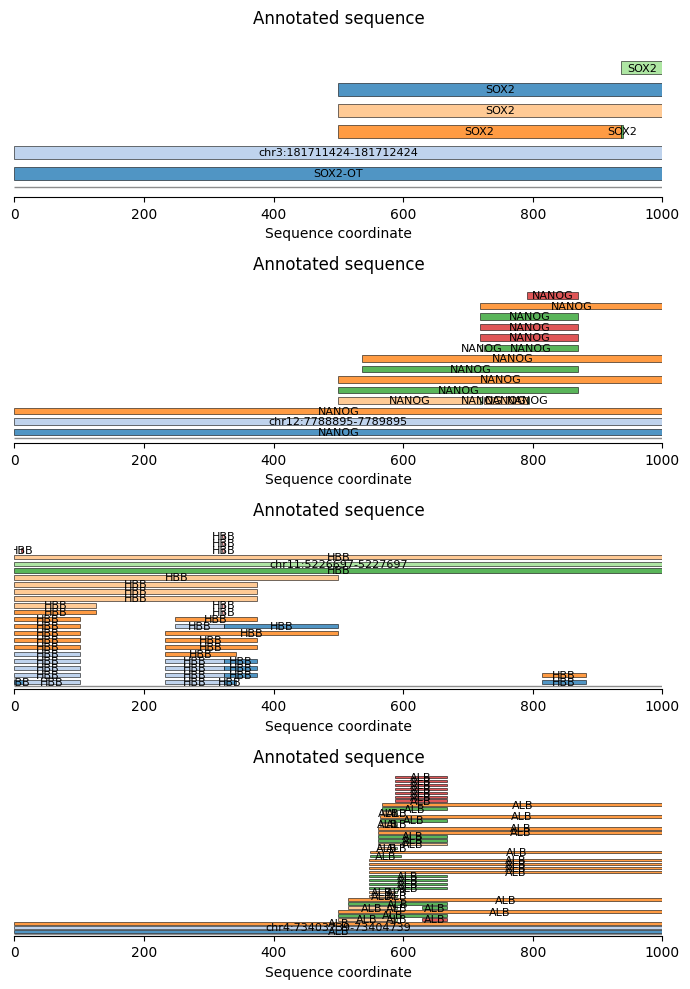

In [6]:
#make sure that TSS is always in the middle
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(7,10))
#plot sox2
Sox2_chrom, Sox2_interval_start, Sox2_interval_end = tss_tes_coords['Sox2'][0], tss_tes_coords['Sox2'][1]-500, tss_tes_coords['Sox2'][1]+500
genome.sequence(Sox2_chrom, Sox2_interval_start, Sox2_interval_end).plot_annotations(ax=axs[0], show_legend=False, hide_types=('source', 'transcript'))
#plot nanog
Nanog_chrom, Nanog_interval_start, Nanog_interval_end = tss_tes_coords['Nanog'][0], tss_tes_coords['Nanog'][1]-500, tss_tes_coords['Nanog'][1]+500
genome.sequence(Nanog_chrom, Nanog_interval_start, Nanog_interval_end).plot_annotations(ax=axs[1], show_legend=False)
#plot HBB
HBB_chrom, HBB_interval_start, HBB_interval_end = tss_tes_coords['HBB'][0], tss_tes_coords['HBB'][1]-500, tss_tes_coords['HBB'][1]+500
genome.sequence(HBB_chrom, HBB_interval_start, HBB_interval_end).plot_annotations(ax=axs[2], show_legend=False)
#plot ALB
ALB_chrom, ALB_interval_start, ALB_interval_end = tss_tes_coords['ALB'][0], tss_tes_coords['ALB'][1]-500, tss_tes_coords['ALB'][1]+500
genome.sequence(ALB_chrom, ALB_interval_start, ALB_interval_end).plot_annotations(ax=axs[3], show_legend=False)

## Single-sequence inference across genes and cell types

This cell creates one prediction for every cell-type/gene combination using `predict_sequence`. It is the most direct version of the workflow and is useful for learning or debugging, although the batched methods shown later are usually faster for larger jobs.

### Constructing a strand-aware input sequence

`offset = NUM_BEFORE * TOKEN_LEN_FOR_FETCH` reserves enough upstream DNA for the tokenizer to obtain its requested 511 pre-anchor tokens.

- On the positive strand, upstream bases have smaller genomic coordinates, so the interval starts at `TSS - offset` and extends downstream to `TES`.
- On the negative strand, upstream bases have larger genomic coordinates. The genomic interval therefore starts at the smaller `TES` coordinate and ends at `TSS + offset`. Passing `strand="-"` makes `Genome.sequence` reverse-complement the result, so the returned `AnnotatedSequence` is again oriented from the gene's upstream side toward its transcribed region.

After either construction, the TSS lies at sequence coordinate `offset`. `add_feature(name="tss", start=offset, end=offset, type="tss")` records that anchor. The feature is essential because `center="tss"` asks the tokenizer to resolve a feature with that name or type.

`Genome.sequence(...)` accepts:

- `chrom`, `start`, and `end`: a 0-based, half-open genomic interval;
- `strand`: `"+"` returns the reference orientation and `"-"` returns the reverse complement with annotations remapped;
- `include_features`: whether overlapping annotation features should be attached, defaulting to `True`;
- `name`: the name stored on the returned `AnnotatedSequence`.

Related genome access methods are `genome.fetch(...)`, which returns a plain DNA string and pads out-of-range bases when necessary; `genome.sequence_around(...)`, which returns a fixed-size `AnnotatedSequence` centered on a genomic coordinate and can add a center feature automatically; and `genome.features(...)`, which retrieves annotation features without fetching DNA.

### Calling `predict_sequence`

`model.predict_sequence(...)` accepts:

- `sequence`: an `AnnotatedSequence` or plain DNA string;
- `condition`: a `Condition`, text string, or metadata mapping;
- `center`: an integer sequence coordinate, a feature name, a `Feature`, or the special string `"middle"`/`"midpoint"`;
- `strand`: an optional tokenizer orientation. Because `Genome.sequence` has already oriented negative-strand genes here, the default `"+"` is correct;
- `grouping`: the forward-layout strategy; for a single row it does not provide a batching advantage;
- `return_tokens`: whether the returned prediction should retain token-to-sequence coordinate metadata.

The return value is an `ExpressionPrediction`. Its `.expression` field contains the expression output, while `.sequence`, `.condition`, `.tokens`, `.outputs`, and `.provenance` retain the inputs and inference metadata. Passing `lookup[cell_type]` directly is valid because the method accepts a metadata mapping. When a meaningful condition name is needed in the returned object, construct a `Condition` explicitly or use `lookup.condition(cell_type)`.

In [118]:
results = []
for cell_type in lookup.keys():
    for gene in tss_tes_coords.keys():
        chrom = tss_tes_coords[gene][0]
        TSS = tss_tes_coords[gene][1]
        TES = tss_tes_coords[gene][2]
        gene_strand = tss_tes_coords[gene][3]
        offset = NUM_BEFORE * TOKEN_LEN_FOR_FETCH
        
        sequence = genome.sequence(chrom=chrom,
                                    start=(TSS - offset) if (gene_strand=='+') else TES,   #----<offset>-------TSS-----TES (+) or ----TES-----TSS-------<offset>--- (-)
                                    end=TES if (gene_strand=='+') else TSS + offset,
                                    strand=gene_strand,
                                    name=gene).add_feature(name='tss', start=offset, end=offset, type='tss')
        
        expression = model.predict_sequence(sequence=sequence,
                                        condition=lookup[cell_type],
                                        center='tss').expression
        results.append(
            (cell_type, gene, expression)
        )

The bar plot compares predicted expression across genes and cell types.

Expected qualitative behavior:

- `ALB` should be high in the liver-derived `HepG2` condition.
- `HBB` should be higher in the blood-related `K562` condition.
- pluripotency-associated genes such as `Sox2` and `Nanog` should be more active in the embryonic stem cell condition `H1`.

In [12]:
def plot_results(results:list):
    df = pd.DataFrame(results)
    df.columns = ['Cell Type', 'Gene', 'Expression']
    print (df)
    plt.figure(figsize=(2.5, 5))
    sns.barplot(x='Gene', y='Expression', hue='Cell Type', data=df, palette='gray')
    plt.xlabel('Gene', fontsize=12)
    plt.ylabel('Expression (log(TPM+1))', fontsize=12)
    plt.grid(True, axis='y')
    plt.show()

   Cell Type   Gene  Expression
0       K562   Sox2    0.061279
1       K562  Nanog    0.135742
2       K562    HBB    2.140625
3       K562    ALB    0.163086
4      HepG2   Sox2    0.259766
5      HepG2  Nanog    0.101562
6      HepG2    HBB    0.117188
7      HepG2    ALB    9.312500
8         H1   Sox2    2.750000
9         H1  Nanog    1.093750
10        H1    HBB    0.064453
11        H1    ALB    0.136719


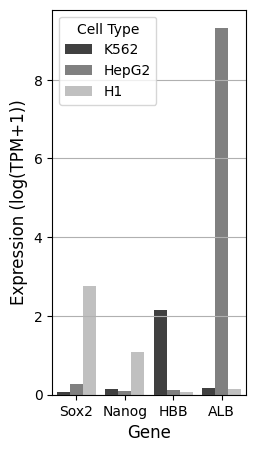

In [113]:
plot_results(results)

# Batch inference

Batch inference accepts a collection of `(sequence, condition)` rows and reduces Python and GPU-launch overhead by organizing compatible rows into forward passes. `predict_multiple_sequences` supports three useful input arrangements:

- multiple sequences plus one `condition`, which broadcasts the condition over every sequence;
- one sequence plus multiple `conditions`, which repeats the sequence for every condition;
- equally sized `sequences` and `conditions`, which are paired row by row as in these examples.

Pass exactly one of `condition=` or `conditions=`. Predictions are returned in the same logical row order as the inputs even when rows are internally rearranged into groups.

The method's remaining arguments are:

- `center`: integer coordinate, feature name, or `Feature` used to anchor DNA tokenization;
- `strand`: tokenizer orientation applied to every sequence in this call;
- `grouping`: one of `"serial"`, `"no_grouping"`, `"condition"`, `"sequence"`, or `"auto"`;
- `preprocessing_workers`: number of CPU workers used to prepare DNA and description tokens; `0` performs preprocessing in the main process;
- `preprocessing_backend`: `"process"` or `"thread"`, with `"process"` as the default;
- `max_records_per_forward`: optional maximum number of rows placed in one forward group; `None` leaves a compatible group intact;
- `prefetch_batches`: number of future CPU batches prepared while the GPU processes the current batch; `0` disables look-ahead;
- `show_progress`: whether meaningful multi-item stages display progress bars;
- `return_tokens`: whether token coordinates are retained in each `ExpressionPrediction`.

## How the grouping modes differ

Think of each input row as one `(DNA sequence, condition description)` pair. Let `N` be the number of rows in one compatible group.

- `serial`: sends one row per model forward. Its logical group is `1 × 1`. This is the simplest reference behavior and is useful for debugging or numerical comparisons, but it performs the most forward calls.
- `no_grouping`: batches independent rows without assuming that either the sequence or condition repeats. A chunk of `N` rows uses `N` independent DNA/description pairs. This is the general-purpose choice for heterogeneous row-wise data.
- `condition`: groups rows that have the same rendered condition text. One condition representation is reused across `N` different DNA sequences. This is efficient when many genes are evaluated in one cell type.
- `sequence`: groups rows whose tokenized DNA IDs are identical. One DNA representation is reused across `N` different descriptions. This is efficient when the same gene or construct is evaluated under many conditions.
- `auto`: compares the amount of repetition in the condition and tokenized-sequence groups. It selects `sequence` when repeated sequences save more work, otherwise selects `condition` when repeated conditions are at least as beneficial, and falls back to `no_grouping` when neither side repeats.

`condition` groups by the final text returned by `Condition.text()`, not merely by `Condition.name`. `sequence` groups by tokenized DNA IDs, so separately created `AnnotatedSequence` objects can still share a group if their model inputs are identical.

For the 12 rows in this example—three cell types and four genes—and with no `max_records_per_forward` limit, the expected high-level organization is:

- `serial`: 12 groups of one row;
- `no_grouping`: one independent batch of 12 rows;
- `condition`: three groups of four genes, one group per cell-type description;
- `sequence`: four groups of three descriptions, one group per gene sequence.

Actual memory use depends on token lengths and model internals, so `max_records_per_forward` should be set when a complete group is too large for the selected device.

## `Condition`: naming and describing a biological context

The batch examples wrap each selected metadata dictionary in a `Condition`. Its required arguments are `name` and `description`. `description` can be a ready-to-tokenize string or a metadata mapping; mappings are converted into natural-language statements before tokenization.

Optional fields are `assay`, `cell_type`, `tissue`, and arbitrary `metadata`. They are useful for tracking and serialization but do not replace the main `description`. `Condition.text()` returns the exact text sent to the description tokenizer, and `Condition.to_dict()` returns a JSON-friendly representation.

## Reference batching with `grouping="serial"`

This cell first materializes the 12 row-wise sequence/condition pairs and then executes each pair in its own model forward. Because the input construction is the same as in the single-sequence example, the main difference is that all rows are submitted through one API call and returned as a list.

`serial` is intentionally conservative. It is useful as a reference path when checking whether more efficient grouping strategies preserve expected results. `preprocessing_workers=10` can still parallelize CPU token preparation, but it does not change the one-row-per-forward GPU layout.

The final loop reads metadata directly from each `ExpressionPrediction`: the named condition, the named sequence, and the expression value.

### Batch Prediction From Genome-Built Sequences

Here we first create `AnnotatedSequence` objects with `genome.sequence_around(...)`.  
This is useful when we want explicit sequence objects with names, genomic features, and a marked TSS position before running the model.

Each row in the batch is one `(sequence, condition)` pair. Since the same TSS sequence is evaluated across multiple cell types, `grouping="sequence"` lets the API reuse repeated DNA representations instead of recomputing them for every condition.

In [127]:
sequences = []
conditions = []
for cell_type in lookup.keys():
    for gene in tss_tes_coords.keys():
        chrom = tss_tes_coords[gene][0]
        TSS = tss_tes_coords[gene][1]
        TES = tss_tes_coords[gene][2]
        gene_strand = tss_tes_coords[gene][3]
        offset = NUM_BEFORE * TOKEN_LEN_FOR_FETCH
        
        sequence = genome.sequence(chrom=chrom,
                                    start=(TSS - offset) if (gene_strand=='+') else TES,   #----<offset>-------TSS-----TES (+) or ----TES-----TSS-------<offset>--- (-)
                                    end=TES if (gene_strand=='+') else TSS + offset,
                                    strand=gene_strand,
                                    name=gene).add_feature(name='tss', start=offset, end=offset, type='tss')
        sequences.append(sequence)
        conditions.append(
            Condition(name=cell_type, description=lookup[cell_type])
            )

predictions = model.predict_multiple_sequences(
    sequences,
    conditions=conditions,
    center="tss",
    return_tokens=True,
    preprocessing_workers=10,
    grouping='serial'
)

results = []
for prediction in predictions:
    results.append(
        (prediction.condition.name, prediction.sequence.name, prediction.expression)
    )

Predicting sequences:   0%|          | 0/12 [00:00<?, ?batch/s]

Predicting sequences: 100%|██████████| 12/12 [00:22<00:00,  1.85s/batch]


   Cell Type   Gene  Expression
0       K562   Sox2    0.061279
1       K562  Nanog    0.135742
2       K562    HBB    2.140625
3       K562    ALB    0.163086
4      HepG2   Sox2    0.259766
5      HepG2  Nanog    0.101562
6      HepG2    HBB    0.117188
7      HepG2    ALB    9.312500
8         H1   Sox2    2.750000
9         H1  Nanog    1.093750
10        H1    HBB    0.064453
11        H1    ALB    0.136719


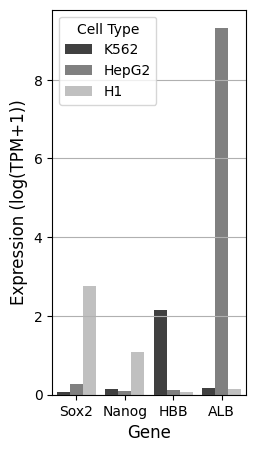

In [128]:
plot_results(results)

## Independent row batching with `grouping="no_grouping"`

This mode keeps every sequence/condition pair independent but places multiple pairs into the same model forward. It makes no assumption that a sequence or condition is repeated, so it is the safest general batching strategy for heterogeneous inputs.

With the current example and `max_records_per_forward=None`, all 12 rows can be assembled into one forward batch. If that is too large for GPU memory, pass a positive `max_records_per_forward`, such as `max_records_per_forward=4`, to split the rows into smaller chunks without changing their meaning or returned order.

Compared with `serial`, this mode usually reduces forward-call overhead while preserving the same no-reuse semantics.

In [124]:
sequences = []
conditions = []
for cell_type in lookup.keys():
    for gene in tss_tes_coords.keys():
        chrom = tss_tes_coords[gene][0]
        TSS = tss_tes_coords[gene][1]
        TES = tss_tes_coords[gene][2]
        gene_strand = tss_tes_coords[gene][3]
        offset = NUM_BEFORE * TOKEN_LEN_FOR_FETCH
        
        sequence = genome.sequence(chrom=chrom,
                                    start=(TSS - offset) if (gene_strand=='+') else TES,   #----<offset>-------TSS-----TES (+) or ----TES-----TSS-------<offset>--- (-)
                                    end=TES if (gene_strand=='+') else TSS + offset,
                                    strand=gene_strand,
                                    name=gene).add_feature(name='tss', start=offset, end=offset, type='tss')
        sequences.append(sequence)
        conditions.append(
            Condition(name=cell_type, description=lookup[cell_type])
            )

predictions = model.predict_multiple_sequences(
    sequences,
    conditions=conditions,
    center="tss",
    return_tokens=True,
    preprocessing_workers=10,
    grouping='no_grouping'
)

results = []
for prediction in predictions:
    results.append(
        (prediction.condition.name, prediction.sequence.name, prediction.expression)
    )

   Cell Type   Gene  Expression
0       K562   Sox2    0.071289
1       K562  Nanog    0.136719
2       K562    HBB    2.140625
3       K562    ALB    0.159180
4      HepG2   Sox2    0.265625
5      HepG2  Nanog    0.107910
6      HepG2    HBB    0.129883
7      HepG2    ALB    9.312500
8         H1   Sox2    2.750000
9         H1  Nanog    1.070312
10        H1    HBB    0.066895
11        H1    ALB    0.127930


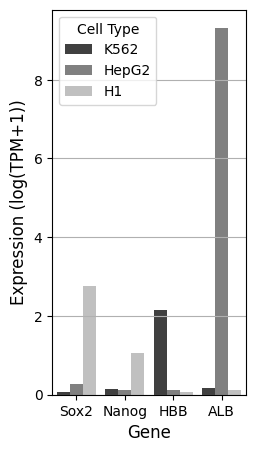

In [125]:
plot_results(results)

## Reusing DNA across conditions with `grouping="sequence"`

This mode is designed for experiments that evaluate the same DNA sequence under several biological conditions. Rows are grouped by their tokenized DNA IDs, and the model's repeated-sequence path reuses the DNA representation while processing the different descriptions in that group.

In this example, the outer loop creates a new Python sequence object for every cell type, but the sequence for a given gene has the same DNA and TSS-centered tokenization each time. Those rows can therefore be grouped together. With three cell types, each gene contributes a group of three condition descriptions.

This mode must tokenize the DNA before it can discover identical tokenized inputs, so batch planning performs a DNA-tokenization stage first. It is a strong choice when the number of conditions per sequence is large enough to justify that planning step.

In [119]:
sequences = []
conditions = []
for cell_type in lookup.keys():
    for gene in tss_tes_coords.keys():
        chrom = tss_tes_coords[gene][0]
        TSS = tss_tes_coords[gene][1]
        TES = tss_tes_coords[gene][2]
        gene_strand = tss_tes_coords[gene][3]
        offset = NUM_BEFORE * TOKEN_LEN_FOR_FETCH
        
        sequence = genome.sequence(chrom=chrom,
                                    start=(TSS - offset) if (gene_strand=='+') else TES,   #----<offset>-------TSS-----TES (+) or ----TES-----TSS-------<offset>--- (-)
                                    end=TES if (gene_strand=='+') else TSS + offset,
                                    strand=gene_strand,
                                    name=gene).add_feature(name='tss', start=offset, end=offset, type='tss')
        sequences.append(sequence)
        conditions.append(
            Condition(name=cell_type, description=lookup[cell_type])
            )

predictions = model.predict_multiple_sequences(
    sequences,
    conditions=conditions,
    center="tss",
    return_tokens=True,
    preprocessing_workers=10,
    grouping='sequence'
)

results = []
for prediction in predictions:
    results.append(
        (prediction.condition.name, prediction.sequence.name, prediction.expression)
    )

Predicting sequences: 100%|██████████| 4/4 [00:00<00:00, 14.03batch/s]


   Cell Type   Gene  Expression
0       K562   Sox2    0.071289
1       K562  Nanog    0.136719
2       K562    HBB    2.140625
3       K562    ALB    0.159180
4      HepG2   Sox2    0.265625
5      HepG2  Nanog    0.107910
6      HepG2    HBB    0.129883
7      HepG2    ALB    9.312500
8         H1   Sox2    2.750000
9         H1  Nanog    1.070312
10        H1    HBB    0.066895
11        H1    ALB    0.127930


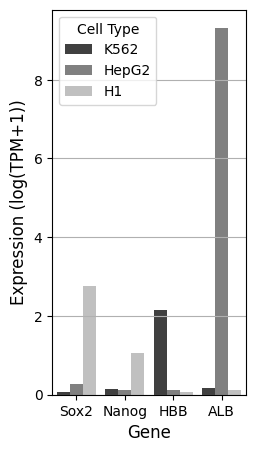

In [126]:
plot_results(results)

## Reusing a condition across sequences with `grouping="condition"`

This mode is the mirror image of `sequence` grouping. Rows with the same rendered condition description are placed together so that one condition representation can be reused across several DNA sequences.

The current loop adds four genes for each cell type, so each condition group contains four different sequences. This is a natural layout for questions such as “What is the predicted expression of many genes in K562?” It is often preferable to `sequence` grouping when the dataset contains more repeated conditions than repeated sequences.

Condition equality for grouping is based on `Condition.text()`. Consequently, two conditions with different display names but identical description text can share the same internal group while retaining their original condition objects in the returned predictions.

In [131]:
sequences = []
conditions = []
for cell_type in lookup.keys():
    for gene in tss_tes_coords.keys():
        chrom = tss_tes_coords[gene][0]
        TSS = tss_tes_coords[gene][1]
        TES = tss_tes_coords[gene][2]
        gene_strand = tss_tes_coords[gene][3]
        offset = NUM_BEFORE * TOKEN_LEN_FOR_FETCH
        
        sequence = genome.sequence(chrom=chrom,
                                    start=(TSS - offset) if (gene_strand=='+') else TES,   #----<offset>-------TSS-----TES (+) or ----TES-----TSS-------<offset>--- (-)
                                    end=TES if (gene_strand=='+') else TSS + offset,
                                    strand=gene_strand,
                                    name=gene).add_feature(name='tss', start=offset, end=offset, type='tss')
        sequences.append(sequence)
        conditions.append(
            Condition(name=cell_type, description=lookup[cell_type])
            )

predictions = model.predict_multiple_sequences(
    sequences,
    conditions=conditions,
    center="tss",
    return_tokens=True,
    preprocessing_workers=10,
    grouping='condition'
)

results = []
for prediction in predictions:
    results.append(
        (prediction.condition.name, prediction.sequence.name, prediction.expression)
    )

Predicting sequences:   0%|          | 0/3 [00:00<?, ?batch/s]

Predicting sequences: 100%|██████████| 3/3 [00:33<00:00, 11.09s/batch]


   Cell Type   Gene  Expression
0       K562   Sox2    0.061279
1       K562  Nanog    0.135742
2       K562    HBB    2.140625
3       K562    ALB    0.163086
4      HepG2   Sox2    0.259766
5      HepG2  Nanog    0.101562
6      HepG2    HBB    0.117188
7      HepG2    ALB    9.312500
8         H1   Sox2    2.750000
9         H1  Nanog    1.093750
10        H1    HBB    0.064453
11        H1    ALB    0.136719


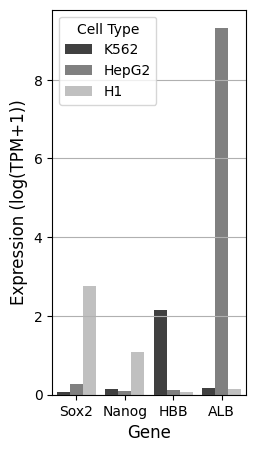

In [132]:
plot_results(results)

# Batch prediction from existing DNA strings

Genome coordinates are convenient when a reference FASTA is available, but the prediction API does not require genome-backed inputs. Existing promoter sequences, synthetic constructs, assembled plasmid fragments, or sequences loaded from another source can be wrapped in `AnnotatedSequence` directly.

The remaining cells show how to preserve the same TSS-centered contract when the TSS is encoded inside a plain string rather than obtained from genomic coordinates.

## Marking the TSS inside each source string

The `@` character is used here as a temporary sentinel that marks the TSS. It is not part of the DNA alphabet and must be removed before tokenization. In a real notebook, the strings would contain the full sequence context needed by the model.

Each source sequence should contain exactly one marker. For production code, validate that the marker exists once; otherwise `str.find('@')` returns `-1` for a missing marker and silently creates an invalid anchor.

In [7]:
gene2seq = {'HBB': 'CTTGAATACCTAAACAGAATCTGTTGTTTCCTTGTGTTTGAAAGTGCTTTCACAGTAACTCTGTCTGTACTGCCAGAATATACTGACAATGTGTTATAGTTAACTGTTTTGATCACAACATTTTGAATTGACTGGCAGCAGAAGCTCTTTTATATCCATGTGTTTTCCTTAAGTCATTATACATAGTAGGCACTGAGAACTCTTTATATCTGAATAAGATATTTAGGAACCACTGGTTTACATATCAGAAGCAGAGCTACTCAGGGCATTTTGGGGAAGATCACTTTCACATTCCTGAGCATAGGGAAGTTCTCATAAGAGTAAGATATTAAAAGGAGATACTTGTGTGGTATTCGAAAGACAGTAAGAGAGATTGTAGACCTTATGATCTTGATAGGGAAAACAAACTACATTCCTTTCTCCAAAAGTCAAAAAAAAAGAGCAAATATAGCTTACTATACCTTCTATTCCTACACCATTAGAAGTAGTCAGTGAGTCTAGGCAAGATGTTGGCCCTAAAAATCCAAATACCAGAGAATTCATGAGAACATCACCTGGATGGGACATGTGCCGAGCACACACAATTACTATATGCTAGGCATTGCTATCTTCATATTGAAGATGAGGAGGTCAAGAGATGAAAAAAGACTTGGCACCTTGTTGTTATATTAAAATTATTTGTTAGAGTAGAGCTTTTGTAAGAGTCTAGGAGTGTGGGAGCTAAATGATGATACACATGGACACAAAAAATAGATCAACAGACACCCAGGCCTACTTGAGGGTTGAGGGTGGGAAGAGGGAGACGATGAAAAAGAACCTATTGGGTATTAAGTTCATCACTGAGTGATGAAATAATCTGTACATCAAGACCCAGTGATATGCAATTTACCTATATAACTTGTACATGTACCCCCAAATTTAAAATGAAAGTTAAAACAAAGTATAGGAATGGAATTAATTCCTCAAGATTTGGCTTTAATTTTATTTGATAATTTATCAAATGGTTGTTTTTCTTTTCTCACTATGGCGTTGCTTTATAAACTATGTTCAGTATGTCTGAATGAAAGGGTGTGTGTGTGTGTGAAAGAGAGGGAGAGAGGAAGGGAAGAGAGGACGTAATAATGTGAATTTGAGTTCATGAAAATTTTTCAATAAAATAATTTAATGTCAGGAGAATTAAGCCTAATAGTCTCCTAAATCATCCATCTCTTGAGCTTCAGAGCAGTCCTCTGAATTAATGCCTACATGTTTGTAAAGGGTGTTCAGACTGAAGCCAAGATTCTACCTCTAAAGAGATGCAATCTCAAATTTATCTGAAGACTGTACCTCTGCTCTCCATAAATTGACACCATGGCCCACTTAATGAGGTTAAAAAAAAGCTAATTCTGAATGAAAATCTGAGCCCAGTGGAGGAAATATTAATGAACAAGGTGCAGACTGAAATATAAATTTTTCTGTAATAATTATGCATATACTTTAGCAAAGTTCTGTCTATGTTGACTTTATTGCTTTTTGGTAAGAAATACAACTTTTTAAAGTGAACTAAACTATCCTATTTCCAAACTATTTTGTGTGTGTGCGGTTTGTTTCTATGGGTTCTGGTTTTCTTGGAGCATTTTTATTTCATTTTAATTAATTAATTCTGAGAGCTGCTGAGTTGTGTTTACTGAGAGATTGTGTATCTGCGAGAGAAGTCTGTAGCAAGTAGCTAGACTGTGCTTGACCTAGGAACATATACAGTAGATTGCTAAAATGTCTCACTTGGGGAATTTTAGACTAAACAGTAGAGCATGTATAAAAATACTCTAGTCAAGTGCTGCTTTTGAAACAAATGATAAAACCACACTCCCATAGATGAGTGTCATGATTTTCATGGAGGAAGTTAATATTCATCCTCTAAGTATACCCAGACTAGGGCCATTCTGATATAAAACATTAGGACTTAAGAAAGATTAATAGACTGGAGTAAAGGAAATGGACCTCTGTCTCTCTCGCTGTCTCTTTTTTGAGGACTTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTTGTGGTCAGTGGGGCTGGAATAAAAGTAGAATAGACCTGCACCTGCTGTGGCATCCATTCACAGAGTAGAAGCAAGCTCACAATAGTGAAGATGTCAGTAAGCTTGAATAGTTTTTCAGGAACTTTGAATGCTGATTTAGATTTGAAACTGAGGCTCTGACCATAACCAAATTTGCACTATTTATTGCTTCTTGAAACTTATTTGCCTGGTATGCCTGGGCTTTTGATGGTCTTAGTATAGCTTGCAGCCTTGTCCCTGCAGGGTATTATGGGTAATAGAAAGAAAAGTCTGCGTTACACTCTAGTCACACTAAGTAACTACCATTGGAAAAGCAACCCCTGCCTTGAAGCCAGGATGATGGTATCTGCAGCAGTTGCCAACACAAGAGAAGGATCCATAGTTCATCATTTAAAAAAGAAAACAAAATAGAAAAAGGAAAACTATTTCTGAGCATAAGAAGTTGTAGGGTAAGTCTTTAAGAAGGTGACAATTTCTGCCAATCAGGATTTCAAAGCTCTTGCTTTGACAATTTTGGTCTTTCAGAATACTATAAATATAACCTATATTATAATTTCATAAAGTCTGTGCATTTTCTTTGACCCAGGATATTTGCAAAAGACATATTCAAACTTCCGCAGAACACTTTATTTCACATATACATGCCTCTTATATCAGGGATGTGAAACAGGGTCTTGAAAACTGTCTAAATCTAAAACAATGCTAATGCAGGTTTAAATTTAATAAAATAAAATCCAAAATCTAACAGCCAAGTCAAATCTGCATGTTTTAACATTTAAAATATTTTAAAGACGTCTTTTCCCAGGATTCAACATGTGAAATCTTTTCTCAGGGATACACGTGTGCCTAGATCCTCATTGCTTTAGTTTTTTACAGAGGAATGAATATAAAAAGAAAATACTTAAATTTTATCCCTCTTACCTCTATAATCATACATAGGCATAATTTTTTAACCTAGGCTCCAGATAGCCATAGAAGAACCAAACACTTTCTGCGTGTGTGAGAATAATCAGAGTGAGATTTTTTCACAAGTACCTGATGAGGGTTGAGACAGGTAGAAAAAGTGAGAGATCTCTATTTATTTAGCAATAATAGAGAAAGCATTTAAGAGAATAAAGCAATGGAAATAAGAAATTTGTAAATTTCCTTCTGATAACTAGAAATAGAGGATCCAGTTTCTTTTGGTTAACCTAAATTTTATTTCATTTTATTGTTTTATTTTATTTTATTTTATTTTATTTTGTGTAATCGTAGTTTCAGAGTGTTAGAGCTGAAAGGAAGAAGTAGGAGAAACATGCAAAGTAAAAGTATAACACTTTCCTTACTAAACCGACATGGGTTTCCAGGTAGGGGCAGGATTCAGGATGACTGACAGGGCCCTTAGGGAACACTGAGACCCTACGCTGACCTCATAAATGCTTGCTACCTTTGCTGTTTTAATTACATCTTTTAATAGCAGGAAGCAGAACTCTGCACTTCAAAAGTTTTTCCTCACCTGAGGAGTTAATTTAGTACAAGGGGAAAAAGTACAGGGGGATGGGAGAAAGGCGATCACGTTGGGAAGCTATAGAGAAAGAAGAGTAAATTTTAGTAAAGGAGGTTTAAACAAACAAAATATAAAGAGAAATAGGAACTTGAATCAAGGAAATGATTTTAAAACGCAGTATTCTTAGTGGACTAGAGGAAAAAAATAATCTGAGCCAAGTAGAAGACCTTTTCCCCTCCTACCCCTACTTTCTAAGTCACAGAGGCTTTTTGTTCCCCCAGACACTCTTGCAGATTAGTCCAGGCAGAAACAGTTAGATGTCCCCAGTTAACCTCCTATTTGACACCACTGATTACCCCATTGATAGTCACACTTTGGGTTGTAAGTGACTTTTTATTTATTTGTATTTTTGACTGCATTAAGAGGTCTCTAGTTTTTTATCTCTTGTTTCCCAAAACCTAATAAGTAACTAATGCACAGAGCACATTGATTTGTATTTATTCTATTTTTAGACATAATTTATTAGCATGCATGAGCAAATTAAGAAAAACAACAACAAATGAATGCATATATATGTATATGTATGTGTGTATATATACACACATATATATATATATTTTTTCTTTTCTTACCAGAAGGTTTTAATCCAAATAAGGAGAAGATATGCTTAGAACCGAGGTAGAGTTTTCATCCATTCTGTCCTGTAAGTATTTTGCATATTCTGGAGACGCAGGAAGAGATCCATCTACATATCCCAAAGCTGAATTATGGTAGACAAAACTCTTCCACTTTTAGTGCATCAACTTCTTATTTGTGTAATAAGAAAATTGGGAAAACGATCTTCAATATGCTTACCAAGCTGTGATTCCAAATATTACGTAAATACACTTGCAAAGGAGGATGTTTTTAGTAGCAATTTGTACTGATGGTATGGGGCCAAGAGATATATCTTAGAGGGAGGGCTGAGGGTTTGAAGTCCAACTCCTAAGCCAGTGCCAGAAGAGCCAAGGACAGGTACGGCTGTCATCACTTAGACCTCACCCTG@TGGAGCCACACCCTAGGGTTGGCCAATCTACTCCCAGGAGCAGGGAGGGCAGGAGCCAGGGCTGGGCATAAAAGTCAGGGCAGAGCCATCTATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACCATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAGTTGGTGGTGAGGCCCTGGGCAGGTTGGTATCAAGGTTACAAGACAGGTTTAAGGAGACCAATAGAAACTGGGCATGTGGAGACAGAGAAGACTCTTGGGTTTCTGATAGGCACTGACTCTCTCTGCCTATTGGTCTATTTTCCCACCCTTAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGAGTCCTTTGGGGATCTGTCCACTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAAGTGCTCGGTGCCTTTAGTGATGGCCTGGCTCACCTGGACAACCTCAAGGGCACCTTTGCCACACTGAGTGAGCTGCACTGTGACAAGCTGCACGTGGATCCTGAGAACTTCAGGGTGAGTCTATGGGACGCTTGATGTTTTCTTTCCCCTTCTTTTCTATGGTTAAGTTCATGTCATAGGAAGGGGATAAGTAACAGGGTACAGTTTAGAATGGGAAACAGACGAATGATTGCATCAGTGTGGAAGTCTCAGGATCGTTTTAGTTTCTTTTATTTGCTGTTCATAACAATTGTTTTCTTTTGTTTAATTCTTGCTTTCTTTTTTTTTCTTCTCCGCAATTTTTACTATTATACTTAATGCCTTAACATTGTGTATAACAAAAGGAAATATCTCTGAGATACATTAAGTAACTTAAAAAAAAACTTTACACAGTCTGCCTAGTACATTACTATTTGGAATATATGTGTGCTTATTTGCATATTCATAATCTCCCTACTTTATTTTCTTTTATTTTTAATTGATACATAATCATTATACATATTTATGGGTTAAAGTGTAATGTTTTAATATGTGTACACATATTGACCAAATCAGGGTAATTTTGCATTTGTAATTTTAAAAAATGCTTTCTTCTTTTAATATACTTTTTTGTTTATCTTATTTCTAATACTTTCCCTAATCTCTTTCTTTCAGGGCAATAATGATACAATGTATCATGCCTCTTTGCACCATTCTAAAGAATAACAGTGATAATTTCTGGGTTAAGGCAATAGCAATATCTCTGCATATAAATATTTCTGCATATAAATTGTAACTGATGTAAGAGGTTTCATATTGCTAATAGCAGCTACAATCCAGCTACCATTCTGCTTTTATTTTATGGTTGGGATAAGGCTGGATTATTCTGAGTCCAAGCTAGGCCCTTTTGCTAATCATGTTCATACCTCTTATCTTCCTCCCACAGCTCCTGGGCAACGTGCTGGTCTGTGTGCTGGCCCATCACTTTGGCAAAGAATTCACCCCACCAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGGTGTGGCTAATGCCCTGGCCCACAAGTATCACTAAGCTCGCTTTCTTGCTGTCCAATTTCTATTAAAGGTTCCTTTGTTCCCTAAGTCCAACTACTAAACTGGGGGATATTATGAAGGGCCTTGAGCATCTGGATTCTGCCTAATAAAAAACATTTATTTTCATTGCAATGATGTATTTAAATTATTTCTGAATATTTTACTAAAAAGGGAATGTGGGAGGTCAGTGCATTTAAAACATAAAGAAATGAAGAGCTAGTTCAAACCTTGGGAAAATACACTATATCTTAAACTCCATGAAAGAAGGTGAGGCTGCAAACAGCTAATGCACATTGGCAACAGCCCCTGATGCATATGCCTTATTCATCCCTCAGAAAAGGATTCAAGTAGAGGCTTGATTTGGAGGTTAAAGTTTTGCTATGCTGTATTTTACATTACTTATTGTTTTAGCTGTCCTCATGAATGTCTTTTCACTACCCATTTGCTTATCCTGCATCTCTCAGCCTTGACTCCACTCAGTTCTCTTGCTTAGAGATACCACCTTTCCCCTGAAGTGTTCCTTCCATGTTTTACGGCGAGATGGTTTCTCCTCGCCTGGCCACTCAGCCTTAGTTGTCTCTGTTGTCTTATAGAGGTCTACTTGAAGAAGGAAAAACAGGGGTCATGGTTTGACTGTCCTGTGAGCCCTTCTTCCCTGCCTCCCCCACTCACAGTGACCCGGAATCTGCAGTGCTAGTCTCCCGGAACTATCACTCTTTCACAGTCTGCTTTGGAAGGACTGGGCTTAGTATGAAAAGTTAGGACTGAGAAGAATTTGAAAGGCGGCTTTTTGTAGCTTGATATTCACTACTGTCTTATTACCCTGTCATAGGCCCACCCCAAATGGAAGTCCCATTCTTCCTCAGGATGTTTAAGATTAGCATTCAGGAAGAGATCAGAGGTCTGCTGGCTCCCTTATCATGTCCCTTATGGTGCTTCTGGCTCTGCAGTTATTAGCATAGTGTTACCATCAACCACCTTAACTTCATTTTTCTTATTCAATACCTAGGTAGGTAGATGCTAGATTCTGGAAATAAAATATGAGTCTCAAGTGGTCCTTGTCCTCTCTCCCAGTCAAATTCTGAATCTAGTTGGCAAGATTCTGAAATCAAGGCATATAATCAGTAATAAGTGATGATAGAAGGGTATATAGAAGAATTTTATTATATGAGAGGGTGAAACCCTCAAAATGAAATGAAATCAGACCCTTGTCTTACACCATAAACAAAAATAAATTTGAATGGGTTAAAGAATTAAACTAAGACCTAAAACCATAAAAATTTTTAAAGAAATCAAAAGAAGAAAATTCTAATATTCACGTTGCAGCCGTTTTTTGAATTTGATATGAGAAGCAAAGGCAACAAAAGGAAAAATAAAGAAGTGAGGCTACATCAAACTAAAAAATTTCCACACAAAAAACAAAACAATGAACAAATGAAAGGTGAACCATGAAATGGCATATTTGCAAACCAAATATTTCTTAAATATTTTGGTTAATATCCAAAATATATAAGAAACACAGATGATTCAATAACAAACAAAAAATTAAAAATAGGAAAATAAAAAAATTAAAAAGAAGAAAATCCTGCCATTTATGGCAGAATTGATGAACCTGGAGGATGTAAAACTAAGAAAAATAAGCCTGACACAAAAAGACAAATACTACACAACCTTGCTCATATGTGAAACATAAAAAAGTCACTCTCATGGAAACAGACAGTAGAGGTATGGTTTCCAGGGGTTGGGGGTGGGAGAATCAGGAAACTATTACTCAAAGGGTATAAAATTTCAGTTATGTGGGATGAATAAATTCTAGATATCTAATGTACAGCATCGTGACTGTAGTTAATTGTACTGTAAGTATATTTAAAATTTGCAAAGAGAGTAGATTTTTTTTTTTTTTTAGATGGAGTTTTGCTCTTGTTGTCCAGGCTGGAGTGCAATGGCAAGATCTTGGCTCACTGCAACCTCCGCCTCCTGGGTTCAAGCAAATCTCCTGCCTCAGCCTCCCGAGTAGCTGGGATTACAGGCATGCGACACCATGCCCAGCTAATTTTGTATTTTTAGTAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGATCCGCCTGCCTCGGCCACCCAAAGGGCTGGGATTACAGGCGTGAGCCACCGGGCCTGGCCGAGAGTAGATCTTAAAAGCATTTACCACAAGAAAAAGGTAACTATGTGAGATAATGGGTATGTTAATTAGCTTGATTGTGGTAATCATTTCACAAGGTATACATATATTAAAACATCATGTTGTACACCTTAAATATATACAATTTTTATTTGTGAATGATACCTCAATAAAGTTGAAGAATAATAAAAAAGAATAGACATCACATGAATTAAAAAACTAAAAAATAAAAAAATGCATCTTGATGATTAGAATTGCATTCTTGATTTTTCAGATACAAATATCCATTTGACTGTTTACTCTTTTCCAAAACAATACAATAAATTTTAGCACTTTATCTTCATTTTCCCCTTCCCAATCTATAATTATATATATATATATTTTAGATATTTTGTATAGTTTTACTCCCTAGATTTTCTAGTGTTATTATTAAATAGTGAAGAAATGTTTACACTTATGTACAAAATGTTTTGCATGCTTTTCTTCATTTCTAACATTCTCTCTAAGTTTATTCTATTTTTTTCTGATTATCCTTAATATTATCTCTTTCTGCTGGAAATACATTGTTACTTTTGGTTTATCTAAAAATGGCTTCATTTTCTTCATTCTAAAATCATGTTAAATTAATACCACTCATGTGTAAGTAAGATAGTGGAATAAATAGAAATCCAAAAACTAAATCTCACTAAAATATAATAATGTGATATATAAAAATATAGCTTTTAAATTTAGCTTGGAAATAAAAAACAAACAGTAATTGAACAACTATACTTTTTGAAAAGAGTAAAGTGAAATGCTTAACTGCATATACCACAATCGATTACACAATTAGGTGTGAAGGTAAAATTCAGTCACGAAAAAACTAG',
 'ALB': 'TCTAAACTCTATCCACTAAAATTTCAACATGAGACTATTTTAGCTATACAATCTTAGTTGTTTTATAGAAGATTGATAAAGTTCAATTTTATAACTTTAAACTTAAGTAACAAGTTTCTTGAATTTCATGTTTAAAATATAGAATATGAATAGATTCAAAGTGCATTCATTTCTGTTTAATTTCCATCTGTGGCTATCCTTATGAGACAGGATTAGTATTAATTTCAATTTATATGTTTATAGATTCTATTAGTTGTTAATTTATTAAGAATGGATAAACATGGATTGCAGACATTAACTATATTTTTCTTGCACTTGAAAAACTTGATAAAAAAATATGAGAAAGTCTCATTAATATAGTTTAAATAAGTTTAAATGAACTTTTTATTCTTTAAAAATATTAAGCTGAACTAGCTAGAGCGTAATACTTGAGGAGCAATTGTGAGGCTTAGGAATGAACAAGCTCTCAAACTTGAATCCTAATTGCCTAACTTGATATATTCTTTCCTACCACTCAGGTCCTTTTCTCATTTGATAAGGCTGTCACATTGAAAACATGGAATTGCAGAATGTTCAAGGTAGAAGGATCGTTAAAGATAATTTAGTCCAACTTGACCCATATGGCATAGAGATATATGCAGATCTGCATGTCCAGTTCTGCAGCTAGAAACTGACACTGAGCTGAATTAAACCACACGGAGAAGAACTGAGAAATTTAAAGTAAAAGGTTAGGAAATTCGAATGTATATATATTCCAGAGGCCCAGTGTAACATGAAGAAAGTCAAGGAGAGGGACTCTTTCATCATGGAAGATCTGGGGGCAGAGGGACTTAAAAGGTGGGACAAGCCAAAGATGGTGACCTAGGGTGGTTTTTATGATATAACCTTTTTTCTCCTCATTCCCTATGAAATCTTCAGCCAATTCCATATTTCTCACTAATTCAAGTGAATATCTGGGGGGATGGCTTATGGAGGGAAATAAGGGAGCAATTGTTTGGATTATATTCCAATTTTTTATTTGCATTAGAATACCTATATGTTTATACATTTTTATTTGCATTAGAAATACTTATATAAGTTTATACACTTTCATTCTAACTTTTTTTGAGGGAAATGTATCTCCATAAGTGAATAAGAAGTTAAATTACTGATTATGTTTCAATTGGTTAGTTTGATGCTTAACAGTCTTTCACTTTTCCACTCTTGCATATTTTGTAGAGAGTAATACAAGCTCTTCATGATAGGAAGGATCTGCATATGTTTATTTTATAGTAGAAAAATGGTAAGATTTTCCTGTCCCCAATTTTCTCTCCAAACAAATCCAAATTTCTTGTATTTTGGAATGACTCTGGGTAAAGTGGTTGTTTATAGAAAGTCTCTTATAAAATATTGAGGATATTATTAGATATTATTACATTTCCATGAATATGTTTCCCTTTATCTTTAAGAGAAGAAGAGTCAGAAATATAACCTATCAGAGTGGGAGATGGCATAAAAGCTGGACTAAATGGATTGCTAGATGGAGGGCAAACCTGGTGTGAATGACTCAGTGAGAAGCTTCGGGAGTCCTGAGGGTAGCAGAAGGGTGCGGATTTAAAGTTACTGTTAGAGTGGCTGGAAAATGGGAGACCGGTTCAGAGACATTTTATCTACTTAAAAACTGTGCCTTTTGTATCACGTCAAAGTGAATGCAAAACAAAGAACAAAAGGGTTAAAGGCTCAGGTTTAAATCCCAGGTATATGTACATTTCAATTGAGGTATTTTTTTTTTCTTTTCTAAATGATCAGTACACTTATTCTTTCTAAAGAAAATACTTTTCTTAACTACTCTCTATTTTTAAACTTCTCCCACAAAGATGAGAAAACATTTAAAAATCATTGGGGCTATTTTTCTGTTTACCGAGTAAAGAGAATCTCTAAACCATATTTATAACTCTTACTCTAAATATTTGCATTTACCCTCATGCCAGAGCCCGTTGATGACTGACTAAACAGAGTTTCAAAGTTTGAAGAACAGGAAATTTAGAAATGACTAACAATTATGTAGGTTTATTTCTCTCAGTATAGAATGTTCATATAGAATTAATGCCAGAGGTTTTCAGAGAAAAATGCAGAAATTTTTACTTTGCAAATCCAGAAGATGCAATTGTTCAAGTATTTCTTAAGAAACATTAATTTTAAGTATGCAGATATCATTGAGAATTAAATATTTTAATTTCTAAACTATTAATCTTTTAGTAGGATGCACATATGCAAAATGCCTCATTAGTACTGTAAGAAAAGATTCTTGGCCGGGCGCGGTGGCTCATGACTGTAATCCCAGCACTTTGGGAGGCCGAGGTGGGCGGATGACGAGGTCAGGAGATCGAGACCACCCTGGCACACGGTGAAACCCCGTCTCTACTAAAGATACAAAAAATTAGCCGGGCGTGATGGCGGGCGCCTGTAGTCCCAGCTACTCGGGAGGCTGAGGCAGAAGAATGGCGTGAACTCGGGAGGCGGAGCTTGCAAGTGAGCCGAGATAGTGCCACTGCACTCCAGTCTGGGCGAAAGAGCGAGACTCCATCTCAAAAAAAAAAAAAAAAAAAGAAAAGATTCTTTTAGGTTTCATCAATTTTGTTTTAAAGCTAGGGCTCTTCATTAGATATAGGAAAATCAATTCAAAGTTTCTATTCAGTCATGATGAATTTGAGATTTTTTTAGGTTTCTTTGTATTTAACAATATATTACATTATAATGTTGTGGTGAAAACTAAATGGACTAATATTATTCTTTTCATTTGTTAAATGAAAAAGTATGCACAAAGTATATGTGAGAGTGACAAAGGCCTGAATTTGTCAATTAGTAACAATTGTATTCAACAGTAAGGATTTTATGTTTGGGTAGGCCTTTCCCAGGGACTTCTACAAGGAAAAAGCTAGAGTTGGTTACTGACTTCTAATAAATAATGCCTACAATTTCTAGGAAGTTAAAAGTTGACATAATTTATCCAAGAAAGAATTATTTTCTTAACTTAGAATAGTTTCTTTTTTCTTTTCAGATGTAGGTTTTTCTGGCTTTAGAAAAAATGCTTGTTTTTCTTCAATGGAAAATAGGCACACTTGTTTTATGTCTGTTCATCTGTAGTCAGAAAGACAAGTCTGGTATTTCCTTTCAGGACTCCCTTGAGTCATTAAAAAAAATCTTCCTATCTATCTATGTATCTATCATCCATCTAGCTTTGATTTTTTCCTCTTCTGTGCTTTATTAGTTAATTAGTACCCATTTCTGAAGAAGAAATAACATAAGATTATAGAAAATAATTTCTTTCATTGTAAGACTGAATAGAAAAAATTTTCTTTCATTATAAGACTGAGTAGAAAAAATAATACTTTGTTAGTCTCTGTGCCTCTATGTGCCATGAGGAAATTTGACTACTGGTTTTGACTGACTGAGTTATTTAATTAAGTAAAATAACTGGCTTAGTACTAATTATTGTTCTGTAGTATCAGAGAAAGTTGTTCTTCCTACTGGTTGAGCTCAGTAGTTCTTCATATTCTGAGCAAAAGGGCAGAGGTAGGATAGCTTTTCTGAGGTAGAGATAAGAACCTTGGGTAGGGAAGGAAGATTTATGAAATATTTAAAAAATTATTCTTCCTTCGCTTTGTTTTTAGACATAATGTTAAATTTATTTTGAAATTTAAAGCAACATAAAAGAACATGTGATTTTTCTACTTATTGAAAGAGAGAAAGGAAAAAAATATGAAACAGGGATGGAAAGAATCCTATGCCTGGTGAAGGTCAAGGGTTCTCATAACCTACAGAGAATTTGGGGTCAGCCTGTCCTATTGTATATTATGGCAAAGATAATCATCATCTCATTTGGGTCCATTTTCCTCTCCATCTCTGCTTAACTGAAGATCCCATGAGATATACTCACACTGAATCTAAATAGCCTATCTCAGGGCTTGAATCACATGTGGGCCACAGCAGGAATGGGAACATGGAATTTCTAAGTCCTATCTTACTTGTTATTGTTGCTATGTCTTTTTCTTAGTTTGCATCTGAGGCAACATCAGCTTTTTCAGACAGAATGGCTTTGGAATAGTAAAAAAGACACAGAAGCCCTAAAATATGTATGTATGTATATGTGTGTGTGCATGCGTGAGTACTTGTGTGTAAATTTTTCATTATCTATAGGTAAAAGCACACTTGGAATTAGCAATAGATGCAATTTGGGACTTAACTCTTTCAGTATGTCTTATTTCTAAGCAAAGTATTTAGTTTGGTTAGTAATTACTAAACACTGAGAACTAAATTGCAAACACCAAGAACTAAAATGTTCAAGTGGGAAATTACAGTTAAATACCATGGTAATGAATAAAAGGTACAAATCGTTTAAACTCTTATGTAAAATTTGATAAGATGTTTTACACAACTTTAATACATTGACAAGGTCTTGTGGAGAAAACAGTTCCAGATGGTAAATATACACAAGGGATTTAGTCAAACAATTTTTTGGCAAGAATATTATGAATTTTGTAATCGGTTGGCAGCCAATGAAATACAAAGATGAGTCTAGTTAATAATCTACAATTATTGGTTAAAGAAGTATATTAG@TGCTAATTTCCCTCCGTTTGTCCTAGCTTTTCTCTTCTGTCAACCCCACACGCCTTTGGCACAATGAAGTGGGTAACCTTTATTTCCCTTCTTTTTCTCTTTAGCTCGGCTTATTCCAGGGGTGTGTTTCGTCGAGATGCACGTAAGAAATCCATTTTTCTATTGTTCAACTTTTATTCTATTTTCCCAGTAAAATAAAGTTTTAGTAAACTCTGCATCTTTAAAGAATTATTTTGGCATTTATTTCTAAAATGGCATAGTATTTTGTATTTGTGAAGTCTTACAAGGTTATCTTATTAATAAAATTCAAACATCCTAGGTAAAAAAAAAAAAAGGTCAGAATTGTTTAGTGACTGTAATTTTCTTTTGCGCACTAAGGAAAGTGCAAAGTAACTTAGAGTGACTGAAACTTCACAGAATAGGGTTGAAGATTGAATTCATAACTATCCCAAAGACCTATCCATTGCACTATGCTTTATTTAAAAACCACAAAACCTGTGCTGTTGATCTCATAAATAGAACTTGTATTTATATTTATTTTCATTTTAGTCTGTCTTCTTGGTTGCTGTTGATAGACACTAAAAGAGTATTAGATATTATCTAAGTTTGAATATAAGGCTATAAATATTTAATAATTTTTAAAATAGTATTCTTGGTAATTGAATTATTCTTCTGTTTAAAGGCAGAAGAAATAATTGAACATCATCCTGAGTTTTTCTGTAGGAATCAGAGCCCAATATTTTGAAACAAATGCATAATCTAAGTCAAATGGAAAGAAATATAAAAAGTAACATTATTACTTCTTGTTTTCTTCAGTATTTAACAATCCTTTTTTTTCTTCCCTTGCCCAGACAAGAGTGAGGTTGCTCATCGGTTTAAAGATTTGGGAGAAGAAAATTTCAAAGCCTTGTAAGTTAAAATATTGATGAATCAAATTTAATGTTTCTAATAGTGTTGTTTATTATTCTAAAGTGCTTATATTTCCTTGTCATCAGGGTTCAGATTCTAAAACAGTGCTGCCTCGTAGAGTTTTCTGCGTTGAGGAAGATATTCTGTATCTGGGCTATCCAATAAGGTAGTCACTGGTCACATGGCTATTGAGTACTTCAAATATGACAAGTGCAACTGAGAAACAAAAACTTAAATTGTATTTAATTGTAGTTAATTTGAATGTATATAGTCACATGTGGCTAATGGCTACTGTATTGGACAGTACAGCTCTGGAACTTGCTTGGTGGAAAGGACTTTAATATAGGTTTCCTTTGGTGGCTTACCCACTAAATCTTCTTTACATAGCAAGCATTCCTGTGCTTAGTTGGGAATATTTAATTTTTTTTTTTTTTTAAGACAGGGTCTCGCTCTGTCGCCCAGGCTGGAGTGCAGTGGCGCAATCTCGGCTCACTGCAAACTCCGCCTCCCGGGTTCACGCCATTCTCCTGCCTCAGCCTCCCGAGTAGCTGGGACTACAGGCGCCCGCCATCACGCCCGGCTAATCTTTTGTATTTTTAGTAGAGATGGGGTTTCACCGTGTGCCAGGATGGTCTCAATCTCCTGACATCGTGATCTGCCCACCTCGGCCTCCCAAAGTGCTGGGATTACAGGAGTGAGCCACCGCGCCCGGCCTATTTAAATGTTTTTTAATCTAGTAAAAAATGAGAAAATTGTTTTTTTAAAAGTCTACCTAATCCTACAGGCTAATTAAAGACGTGTGTGGGGATCAGGTGCGGTGGTTCACACCTGTAATCCCAGCACTTTGGAAGGCTGATGCAGGAGGATTGCTTGAGCCCAGGAGTTCAAGACCAGCCTGGGCAAGTCTCTTTAAAAAAAACAAAACAAACAAACAAAAAAATTAGGCATGGTGGCACATGCCTGTAGTCCTAGCTACTTAGGAGGCTGACGTAGGAGGATCGTTTGGACCTGAGAGGTCAAGGCTACAGTGAGCCATGATTGTGCCACTGCACTCCAGCCTGGGTGACAGAGTGAGACTCTGTCTCAAAAAAGAAAAAGGAAATCTGTGGGGTTTGTTTTAGTTTTAAGTAATTCTAAGGACTTTAAAAATGCCTAGTCTTGACAATTAGATCTATTTGGCATACAATTTGCTTGCTTAATCTATGTGTGTGCATAGATCTACTGACACACGCATACATATAAACATTAGGGAACTACCATTCTCTTTGCGTAGGAAGCCACATATGCCTATCTAGGCCTCAGATCATACCTGATATGAATAGGCTTTCTGGATAATGGTGAAGAAGATGTATAAAAGATAGAACCTATACCCATACATGATTTGTTCTCTAGCGTAGCAACCTGTTACATATTAAAGTTTTATTATACTACATTTTTCTACATCCTTTGTTTCAGGGTGTTGATTGCCTTTGCTCAGTATCTTCAGCAGTGTCCATTTGAAGATCATGTAAAATTAGTGAATGAAGTAACTGAATTTGCAAAAACATGTGTTGCTGATGAGTCAGCTGAAAATTGTGACAAATCACTTGTAAGTACATTCTAATTGTGGAGATTCTTTCTTCTGTTTGAAGTAATCCCAAGCATTTCAAAGGAATTTTTTTTAAGTTTTCTCAATTATTATTAAGTGTCCTGATTTGTAAGAAACACTAAAAAGTTGCTCATAGACTGATAAGCCATTGTTTCTTTTGTGATAGAGATGCTTTAGCTATGTCCACAGTTTTAAAATCATTTCTTTATTGAGACCAAACACAACAGTCATGGTGTATTTAAATGGCAATTTGTCATTTATAAACACCTCTTTTTAAAATTTGAGGTTTGGTTTCTTTTTGTAGAGGCTAATAGGGATATGATAGCATGTATTTATTTATTTATTTATCTTATTTTATTATAGTAAGAACCCTTAACATGAGATCTACCCTGTTATATTTTTAAGTGTACAATCCATTATTGTTAACTACGGGTACACTGTTGTATAGCTTACTCATCTTGCTGTATTAAAACTTTGTGCCCATTGATTAGTAACCCCTCGTTTCGTCCTCCCCCAGCCACTGGCAACCAGCATTATACTCTTTGATTCTATGAGTTTGACTACTTTAGCTACCTTATATAAGTGGTATTATGTACTGTTTATCTTTTTATGACTGACTTATTTCCCTTAGCATAGTGCATTCAAAGTCCAACCATGTTGTTGCCTATTGCAGAATTTCCTTCTTTTCAAGGCTGAATAATATTCCAGTGCATGTGTGTACCACATTTTCTTTATCCATTAATTTGTTGATTGATAGACATTTAGGTTGGTTTTCTACATCTTGACTATCATGAATAGTGTTGCAATGAACACAGGAGAGCTACTATCTCTTAGAGATGATATCATGGTTTTTATCATCAGAAAACACCCACTGATTTCTATGCTAATTTTGTTACCTGGGTGGAATAATAGTACAGCTATATATTCCTCATTTTAGATATCTTTGTATTTCTACATACAATAAAAAAGCAGAGTACTTAGTCATGTTGAAGAACTTTAAACTTTTAGTATTTCCAGATCAATCTTCAAAACAAGGACAGGTTTATCTTTCTCTCACCACTCAATCTATATATACCTCTTGTGGGCAAGGCCAGTTTTTATCACTGGAGCCTTTCCCCTTTTTATTATGTACCTCTCCCTCACAGCAGAGTCAGGACTTTAACTTTACACAATACTATGGCTCTACATATGAAATCTTAAAAATACATAAAAATTAATAAATTCTGTCTAGAGTAGTATATTTTCCCTGGGGTTACAGTTACTTTCATAATAAAAATTAGAGATAAGGAAAGGACTCATTTATTGGAAAGTGATTTTAGGTAACATTTCTGGAAGAAAAATGTCTATATCTTAATAGTCACTTAATATATGATGGATTGTGTTACTCCTCAGTTTTCAATGGCATATACTAAAACATGGCCCTCTAAAAAGGGGGCAAATGAAATGAGAAACTCTCTGAATGTTTTTCTCCCCTAGGTGAATTCACCTGCTGCTTAGAAGCTTATTTTCTCTTGATTTCTGTTATAATGATTGCTCTTACCCTTTAGTTTTAAGTTTCAAAATAGGAGTCATATAACTTTCCTTAAAGCTATTGACTGTCTTTTTGTCCTGTTTTATTCACCATGAGTTATAGTGTGACAGTTAATTCTTATGAAAATTATATAGAGATGGTTAAATCATCAGAAACTGTAAACCTCGATTGGGAGGGGAAGCGGATTTTTAAATGATTTCCTGACCAAGCTTAACCAGTATATTAAATCCTTTGTACTGTTCTTTGGCTATAAAGAAAAAAGGTACTGTCCAGCAACTGAAACCTGCTTTCTTCCATTTAGCATACCCTTTTTGGAGACAAATTATGCACAGTTGCAACTCTTCGTGAAACCTATGGTGAAATGGCTGACTGCTGTGCAAAACAAGAACCTGAGAGAAATGAATGCTTCTTGCAACACAAAGATGACAACCCAAACCTCCCCCGATTGGTGAGACCAGAGGTTGATGTGATGTGCACTGCTTTTCATGACAATGAAGAGACATTTTTGAAAAAGTAAGTAATCAGATGTTTATAGTTCAAAATTAAAAAGCATGGAGTAACTCCATAGGCC',
 'Sox2': 'GAAGAATCAAGCTTTGGTCATTCCGGAAGTCGTGTAGCATGCTCCAATTTGAAGTGACTGAGATCTTTTGTGACTTACAGAGGAGAAGGAAATGTTTTAAAAATTGGCTTATGCCAGTCTCCTTACTCTGAAATTCTCAATTTTCTTGTATTACAGGATAAATATAAATATCATCTCACCAAATTGTACCAGCATTGTCCTAAACATTTAAATTTTCCTTTATTTTTGGCCTTTAAAATTAGAAAATTTTCTCCAGTTGCTGCACTTAGCTTTTTAATTTTGTTTTCTTTTCACTTACCAGACTACTGGTATGATCTCTTTCACTGCAGTATGATTGCTGCTATGGTCACTTTTAGAGGAGATTGTGGGAAGGTTAGGATTTGGAGGAAACATGACAAAAAAGGGAAGAAAAAAAAAAACCTTCATTTGACCACATCTGGCTGCTTGTATATTTAACCAGTTCTAGAATTAGAAAACCTTTCTGTACATTTTCTTCTATTTTTCTCACTTTTTTCCTTACATAATGAAATTAAAACTTTTGGAGCCTACAGTTGACATTTTTCAGAAAATTGAGTTATCAAGGCAGTAATTATTTCACGGGGAGATAAAACTCTCATAGCCCTAACTGTCAAATAGGGCCCTTTTCAGATTTTAATTACAAAATAAAATTAGTCTGCTCTTCCTCAGAATGGTTTGTGAGTGGTTAAACAGAGCTTTCCCCCAATACTGGTGGTCGTCAAACTCTGCTAATTAGCAATGCTGAGAAATTCCAGTTAACAAGGACATTCTCCAAGACTCTGCAGGTTCCCTGCCGTTTGCCTTCATTTCCATAAGAAGATTAAGAGAGGAGGGGAACACACTCAAATGCAGATGCAGAAAAGAAGCGTTTTTTAACAAGCATCATAATAGTAAGATGCTTGGCTAGTTCTCACCTAATTACTGCAAGTTAAACCTCTATTTGACACTAAGAAGAAAAAATAAGTCTACAGTCCCCTGTCTCCACAAAATTGTTAGTTGGTTTCAGATATAATACTTGAGGAGTGCTGAGGAGACTTTAGGAGAGAAAAATCAATGTGCAAGATTTTGAAATAAAATTGAGTTACACTTAACAGTTAAGGCCTTTTGGCTAGGGCCTATAATAGAACAAAATAAAATCAGAATATTCCAGGAGTCATGCATTTTTGTTACTAACTACTAATCTTGCTCTAAAAGTATGTAGCTTTTTGTTGCCCGTGGAAGGGAAGTGTTACACTCCCTTTAGATTAAGCACTTTCAATTTTCGTAAATTGTGCCAATGGCAACATTTTAGATTCTCAGAGGATGAAGCATCCTGTTCCAAGTCTTTTTTGATTGTCTAGTAGTCAATGGTATATTGTTGTTAGTACTGTAGCTGTCTATTACAAACCTAAAACAGTGTTGCTTCTGTCATCTATTGGAATCGTTATAGTTATTATATTTAGGGATCAGTGATGGTGCTGGATTGAAATAGAGTGGGCAGTGATCTGATTTTTTAAAATGCATATGTTCTAAAAAATCTAATGAGAAAATGTTCCTGCTATCACCATCTTCTTTAATCTTATTTTCATAGCACATTATTATGCATAATCGCCAGCCACAGTTAGTTTATTGTCTCGATAAGTACAGCAGGCTTAATTAAAATAAAGCTGTAAATAAATGCAACCAATGATAACACAATTGTAACGTAATTCCATAGCTTATTAATGTGATAAAAGCAATTAATAAAAGACCTAGCCAACCCCTTTAACCTCTTAAATACATTATTATAGAGTTCATGCACAAACACATGCATCTGAGAATGTGTAAAAGTTGTTATATATCCTCCCAAGGAAAAAAATTGTGCCTTGAGAGAAAGGCAACGAGATTTAAAAGATTTGTGTCTATAACCGTCTGTTATTAGTATTTATTTTAACAAATATACACCACCCTTATCCACACCAATTCCTTGGTTGTTTCTTCAAACAATTATCCACAAGCTTTTTAAAGTTTTTAGAATAATGCTATTAAGCAGACCGATGCATACACAATCATAAAGTGAATTCTTGGTCTGCCCTTTGTGGCGTCTGGACAATCATAATTCATTCACATGTTGAATCTCATAATTTGTACCTATTTTTTCCCATGGTCTAACCTCCCACTTACCTCGAGGTTGTATGTATATTTCTAAGTTAGGCAAATTAAATCTGATTCTTATGATTTGGTTCCGCAGCTTATAAGATATGTTAACTTTTCTTTTGTTTAGATTATGTATAATTAGTCTGATCTTCCATCCCCCTCTTTTTTTTTTTTTTACTTTAATTATTTTCAAATACCTTCTTTTAAAGGTAAAAGCAATAGTCTTGGAAAAGCGAATCTACCAGCAGGGGGCGCACCAGCCACATCCCTGAAACCAGCCGCGCTGAAAAGCCGGTGGCCGCCTTCTCTTCCCCAGATCTTCTCAACCTTTTCTCTTTCCTAATCTCCAGGTCCGTGTTTACCTTAATATTACACCTGGATTAAACAGAAAACAGTGCTGTATTTTGAAGAGCGCCGAATATGTATGCATTTTGAGAAACCCAATCTCACCCTTTCCGGGTTCCCAAGAACTAAAACAAGCCATAACTTGAGAGAAAAAGGAGAACCTTCGGGGGGCAGGAAGGTTGATTGGAAATAACTTAAGGAAAGTCTGCAGAATTCTTTTTTTTACAACTTTTCTGAGTTTCCAGTGGGTATATTTAGTGTGAGTTTGACAGTAACAGGCTAGGGAGGGCAGAGATTGGAGAAATTGGGGGTCGGGGGAGTGATTATGGGAAGAAGGTTAGTAAGGAACAAAACAATGCACCGTTTTGTAAAGATAATAAATGGAACGTGGCTGGTAGATACTATTCAGTACATTTTCTTAGGGTGAGTAAGGGTAGACCAGGGGAGGAGGGGGCGGAGAGAGTGTTACAGAAGAAAGAAAATAAGTAACCCTGATGGTTTAAGCCCTTTATAAAAAAGAAATGGCATCAGGTTTTTTTTTCTTTATTCCCCCCCACCCCACCCTTTGTAGTCAAGTGCATTTTAGCCACAAAGATCCCAACAAGAGAGTGGAAGGAAACTTAGACGAGGCTTTGTTTGACTCCGTGTAGCGACAACAAGAGAAACAAAACTACCTATTTGTAACGGACGTGCTGCCATTGCCCTCCGCATTGAGCGCCTACCTATTGAAATCTTTACGTCGGGACAATGGGAGAGCGGCTAAAATTACCCTCTTGGGTCCTGGGCGGGCAAGATTCCTGAGCCCCTACCCCCGCCCCCATCTCATCCTCCTCTAACCCGGGCCTTGCTGGGCTCCCCCTTCCCCAGTCCCGGCCGCCTTCTCCCAGTGTGCGCTGCCTGCACCTGTGCCTGGAGAGCATCGACCCCGCCTCCCAGGCCTTGAGCCCCTTTGCGGCGCAGCCCCAGCCTTGCGCGGCCTGGGCTTTGCGGCCACCACAATGGAAATCTACGGGGAAAATGCCAGGGCTGGTTCTGCTGGAGTCCTGGGAACTCTGCGTGGGAGGGAGTTTGTGACTGCGGCCCAAAAGCCACCTCCATACAGTGCCGTGGGATGCCAGGAAGTTGAAATCACCCTCCCCCATCGCCTGCACTTTTGAGCGCCCTTCCGTCTGTGTCTTTCCCCAGCCCCCATTTGAAAGCCGCACGACCGAAACCCTTCTTACGGGGAGGCATGGGATGGGAATGGGGAGTGGGGGCAGACAGTAGAAGCATCCCCTTTGCTACGGTTGAATGAAGACAGTCTAGTGGGAGATGTGGCTGGGGCTAAGAGGAAGAGCTGCAGTTTCCTGGGCCAAAGAGCTGAGTTGGACAGGGAGATGGCAGCTTACCAAGGCCTGCTGGTTCTCAGCTCTAGAGTCTGCCTTATGGTCCGAGCAGGATTTATTTTTAAGAACAGAGCAAGTTACGTGGAAGCAAGGAAGGTTTTGAGGACAGAGGTTTGGGTCTCCTAACTTCTAGTCGGGACTGTGAGAAGGGCGTGAGAGAGTGTTGGCACCTGTAAGGTAAGAGAGGAGAGCGGAAGAGCGCAGTACGGGAGCGGCACCAGAGGGGCTGGAGTTGGGGGGGAGTGCTGTGGATGAGCGGGAGAACAATGACACACCAACTCCTGCACTGGCTGTTTCCAGAAATACGAGTTGGACAGCCGCCCTGAGCCACCCACTGTGCCCTGCCCCACCCCCGCACCTTAGCTGCTTCCCGCGTCCCATCCTCATTTAAGTACCCTGCACCAAAAAGTAAATCAATATTAAGTTTAAAGAAAAAAAAACCCACGTAGTCTTAGTGCTGTTTACCCACTTCCTTCGAAAAGGCGTGTGGTGTGACCTGTTGCTGCGAGAGGGGATACAAAGGTTTCTCAGTGGCTGGCAGGCTGGCTCTGGGAGCCTCCTCCCCCTCCTCGCCTGCCCCCTCCTCCCCCGGCCTCCCCCGCGCGGCCGGCGGCGCGGGAGGCCCCGCCCCCTTTCATGCAAAACCCGGCAGCGAGGCTGGGCTCGAGTGGAGGAGCCGCCGCGCGCTGATTGGTCGCTAGAAACCCATTTATTCCCTGACAGCCCCCGTCACATG@GATGGTTGTCTATTAACTTGTTCAAAAAAGTATCAGGAGTTGTCAAGGCAGAGAAGAGAGTGTTTGCAAAAGGGGGAAAGTAGTTTGCTGCCTCTTTAAGACTAGGACTGAGAGAAAGAAGAGGAGAGAGAAAGAAAGGGAGAGAAGTTTGAGCCCCAGGCTTAAGCCTTTCCAAAAAATAATAATAACAATCATCGGCGGCGGCAGGATCGGCCAGAGGAGGAGGGAAGCGCTTTTTTTGATCCTGATTCCAGTTTGCCTCTCTCTTTTTTTCCCCCAAATTATTCTTCGCCTGATTTTCCTCGCGGAGCCCTGCGCTCCCGACACCCCCGCCCGCCTCCCCTCCTCCTCTCCCCCCGCCCGCGGGCCCCCCAAAGTCCCGGCCGGGCCGAGGGTCGGCGGCCGCCGGCGGGCCGGGCCCGCGCACAGCGCCCGCATGTACAACATGATGGAGACGGAGCTGAAGCCGCCGGGCCCGCAGCAAACTTCGGGGGGCGGCGGCGGCAACTCCACCGCGGCGGCGGCCGGCGGCAACCAGAAAAACAGCCCGGACCGCGTCAAGCGGCCCATGAATGCCTTCATGGTGTGGTCCCGCGGGCAGCGGCGCAAGATGGCCCAGGAGAACCCCAAGATGCACAACTCGGAGATCAGCAAGCGCCTGGGCGCCGAGTGGAAACTTTTGTCGGAGACGGAGAAGCGGCCGTTCATCGACGAGGCTAAGCGGCTGCGAGCGCTGCACATGAAGGAGCACCCGGATTATAAATACCGGCCCCGGCGGAAAACCAAGACGCTCATGAAGAAGGATAAGTACACGCTGCCCGGCGGGCTGCTGGCCCCCGGCGGCAATAGCATGGCGAGCGGGGTCGGGGTGGGCGCCGGCCTGGGCGCGGGCGTGAACCAGCGCATGGACAGTTACGCGCACATGAACGGCTGGAGCAACGGCAGCTACAGCATGATGCAGGACCAGCTGGGCTACCCGCAGCACCCGGGCCTCAATGCGCACGGCGCAGCGCAGATGCAGCCCATGCACCGCTACGACGTGAGCGCCCTGCAGTACAACTCCATGACCAGCTCGCAGACCTACATGAACGGCTCGCCCACCTACAGCATGTCCTACTCGCAGCAGGGCACCCCTGGCATGGCTCTTGGCTCCATGGGTTCGGTGGTCAAGTCCGAGGCCAGCTCCAGCCCCCCTGTGGTTACCTCTTCCTCCCACTCCAGGGCGCCCTGCCAGGCCGGGGACCTCCGGGACATGATCAGCATGTATCTCCCCGGCGCCGAGGTGCCGGAACCCGCCGCCCCCAGCAGACTTCACATGTCCCAGCACTACCAGAGCGGCCCGGTGCCCGGCACGGCCATTAACGGCACACTGCCCCTCTCACACATGTGAGGGCCGGACAGCGAACTGGAGGGGGGAGAAATTTTCAAAGAAAAACGAGGGAAATGGGAGGGGTGCAAAAGAGGAGAGTAAGAAACAGCATGGAGAAAACCCGGTACGCTCAAAAAGAAAAAGGAAAAAAAAAAATCCCATCACCCACAGCAAATGACAGCTGCAAAAGAGAACACCAATCCCATCCACACTCACGCAAAAACCGCGATGCCGACAAGAAAACTTTTATGAGAGAGATCCTGGACTTCTTTTTGGGGGACTATTTTTGTACAGAGAAAACCTGGGGAGGGTGGGGAGGGCGGGGGAATGGACCTTGTATAGATCTGGAGGAAAGAAAGCTACGAAAAACTTTTTAAAAGTTCTAGTGGTACGGTAGGAGCTTTGCAGGAAGTTTGCAAAAGTCTTTACCAATAATATTTAGAGCTAGTCTCCAAGCGACGAAAAAAATGTTTTAATATTTGCAAGCAACTTTTGTACAGTATTTATCGAGATAAACATGGCAATCAAAATGTCCATTGTTTATAAGCTGAGAATTTGCCAATATTTTTCAAGGAGAGGCTTCTTGCTGAATTTTGATTCTGCAGCTGAAATTTAGGACAGTTGCAAACGTGAAAAGAAGAAAATTATTCAAATTTGGACATTTTAATTGTTTAAAAATTGTACAAAAGGAAAAAATTAGAATAAGTACTGGCGAACCATCTCTGTGGTCTTGTTTAAAAAGGGCAAAAGTTTTAGACTGTACTAAATTTTATAACTTACTGTTAAAAGCAAAAATGGCCATGCAGGTTGACACCGTTGGTAATTTATAATAGCTTTTGTTCGATCCCAACTTTCCATTTTGTTCAGATAAAAAAAACCATGAAATTACTGTGTTTGAAATATTTTCTTATGGTTTGTAATATTTCTGTAAATTTATTGTGATATTTTAAGGTTTTCCCCCCTTTATTTTCCGTAGTTGTATTTTAAAAGATTCGGCTCTGTATTATTTGAATCAGTCTGCCGAGAATCCATGTATATATTTGAACTAATATCATCCTTATAACAGGTACATTTTCAACTTAAGTTTTTACTCCATTATGCACAGTTTGAGATAAATAAATTTTTGAAATATGGACACTGAAATTATTCTTGAGTCTTTCATTTATTTGGATAACACTGTGATTATACATAACTTTTCGGGGAATTATAATACTGTGCTCAGCCAAGAAAGCAAAATACCAAAAACCTTGGTATTACTAGTCCAGCATCATGTGCTAATGTTAACTGCAAAAAAGAAACGGCTGGATGATTAATAAGTACTGGAAAAATTGAAATTTCTGTCATTTCTAAAATAGAAACTAGAGACATATATTGTAAATCCGCCCCCTCCTTTTCTAAGCAGCATGAATAAGCATGATGGGGACCTATACTTAAAACTGATTTATGCCACTTGTTGCCAGAAAGGATTCAATTCTGAAATTTTTCATGTAGTTTAGCAGATGGGATATTGAGCCAAATCAGAACCAGGTTGGCTGGTTTTGTTTTCATTTTCTTCACAGCACAATGGCCCTTTGAAACCTGGCTATAGAGAAAAATGATGCTTCTTGTATCAGAATAATTGCAAACTAGACATGCAAAGTGTTCATCTGCTGGGTGGGTGTTTGGATTACTCTGGCCCTGCTATTGTCTGAGAGGAAACAAGTGGTTTGCTTTCTTTGTTCCTTGACTTCATAAACTTTCTCCTCTACATTTTCCTGTTCGGGGAGAGGGAAAGAAAAGAACATCTTGCAAAACTCCCCGGCTTATCATAAACATAGTTTTTTTTATTATTTATTTTCTTTTTTCCCCTCTCTCTCCCTCTCTCCCTGAATTCCATTTCTTAAATTGGCAGCGCGGGTCCAAGCCTGTAGCCCCAAATCGGATAATCTCTGCAGCTGATAACAAGCAAAAGAGAAGCCAGGCAACAGCCATATTAAAGAAGAAAACAATCAACTCTGAGGTAGATATTTTACTTTGTCCGGTCTAATCACATTTGGAGATGATTATGCTTTTGATCTGTTAACAATGTTTTACTACTGTAGTAGAGAAGTGGGGGAGGGGAAAGGGGTGGGGAAACAAGATTGGATTTGTTGTGTGGTGGTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGCCCTAGGAAAGGTAAAGAAAGGCTATAGTTGTCCTCAGTGGGAGTGGAAAAGTTGAGACATCGCCATGGTCTTTGAATTAGCGATGCTTCTGCATCACCACCCACCCTTGCTTTGGGGCAGCCGGATAATCTGTTACCTAGTCAGGGACTTTTCTACTTTATTTACTACTTGATTCGCTCGTCTTCCCCCACCCACGGGGACCAGGAACCAACAATCGGGCACTTTTAAGAGCACGGGTTTGCTTCCCACAATTTCAAGAGCTTGTGTCAACTTGCTACAACTTTGGAGAAGTTGGAATCCGGCAGCGTCTTCCACCCTTGAGTAAAGTACCCGCTGCAGCCACTAAGTTAGCTCATCCCGTTGGTTTGCATCTTCTCATTTCCAAGAAAGTATTTCTTTCTCATGGTGTTGCTAATGTTAGTTCTGGGCTGAACTGAGGATATCTCATATTTTCTGTACTTTCTATTTTTTTCTAGATTGCTTTGTTTTAGATATGTACTGGTTTTTATTTATTACTTTTTTAATCCTCATTTTTAGGATAACATTGTACTGGGAAGGGACAATTATTATTCCAGTTCCCAATTCTAAGCAAGGCATTTTCCCCCCTAATTAATGCAGAGACTCTAAAAGAATTTCCCCTAGCCTGGCCAGCCATTGTAATGCATATACGGATTATTCACGTGGTAATGAGCACATTCGCCAGTTCTTGCTCACACATACGAATAAAAGAAACTTTGAATAAAGATCCAAATGATCATCCTGGGGGAGTGGGGAGGATATTCCCGGAATTTGAGGCAGTCAAATATATAGATTATATATATTTTGAAAATAGAAATATATTAGAAATATGTATAGAGGTTTACAGTAATTGCACTGCACTCACCTCTCATTTTTTAAAAAAAAGCCCACAGGGTCAGCAACTTTCTGGCAAAATGGTCAGGTTCAAATATTTAGCAAAAGGAAAGGGAGCACAATATTTTGGGAAGTAGAACTAGCTTTGAATAATTGTCACTATCTGCATAAAACAAGAGAACTCCC',
 'Nanog': 'TAGGGGTTAAAAAGAAATCCCTTTTTACATTGGGTCAAAGGTCCCCTGAGGGTAGGGTGGGAAGGAGGAAGTCATAAATACCCTGGCAACAATAGTGTTGGTCAAGGTCAGGACCATTTTTTTTTCCTCCTATTTTTCAGGAACCAAAAAATGGTCAGGACTATTTTTGACAATTCGGCTTGATGGTTTAGTCTTCTGAACTCTCCAGTAGACCTTAGAACTTGGTATACATAGTAATTCAGTCCTTGAATATTAAAAGCCTTTAGTTAGAGTAAGATCTGACAAATTCAAAGCTGAGCCGTGAGTCAGAAATTTTTTTCTCAGCACCATAGGAAAAAAATCATAATAAAAAAATTAAGAGAAGAAATGTGTTGTTTTGTTTTGGGTTATTTTTTTGAGACGGAATTTCGCTCTTGTTGCCCAGGCTGGAGGGCAATGGCGTGATCTTGGCTCACCGCAACCTCTGCCTCCTGGGTTCAAGCGATTCTCCTGCCTCAGCCTCCTGAGTAGCTGGAATTACAAACACATGCCACCATCCTTGGCTAATTTTTGTATTTTTAGTAGAGACAGGATTTTACCATGTTGGTCAGGCTGGTCTCGAACTCCTGACCTCGTGATCCGCCCGCCTCGGCCTCCCAAAGTGCTGGGATTACAGGCGTGAGCCACTGCACCTAGCTGCTTGTGTTTTTATAGGTATAACAGGCAAAATAAGTGAAGAATATGCTGTATAATTCCATCTGTAATCTTCAAACTAGCAGTTTCCGTAGCTGTGGTGTTCATCTTCCCATCATTGGTAATTGGAGAGTAACTCTACCTCCCAGAGGAAGGAGGACTGTTGTAAATTAAAGGCTCATTGTTCAAGCCTCATTGAATTGTCAGTGTAGGGGACCTGAGGCAAAGAGCATTGTTGTTTTCAAGAGTTATTCTGTATATCACATTGATGTGCAGTTCAATATTTAAATGTAAGGAAATGACTCCTACTCTCTATTTGTTTACAAAACCCTAGTTCTCATTTATGCCCATTCCTTCATCAACAAATAATGATTTTCTACTTTTTGCCTGGTTCTCTCTAGAAGAGTAGTTCTTAAACAATAGCATTCAGAAAAATCACCTGGTTTCAATGGTAGGCTGTCATGAAAAAAAAAAAAAAATCACAGGGAGAATTTTAAAACACAGATTCCTGGTCCCAACCACCAAAGATTCCTATTCAGTGGTGAAGCCCATCAATCAGCATCTCTAACAAGCTTCCAAGTGGTGCTGAGGATGCTGGTGAATGATCCATTCATACTCTTCTAGGGCTGTAGATAATAAATTAAACAGGCAAAAATAAAAATAGGCTGGCGCGGTGGCTTACACCTGTAATCCCAGCACTTTGGGAGGCCAAGGTGGGTGGACCACCTGAGGTCAGGAGTTCTAGACCAGCCTGGCCAACATGGTGAACCCCGTCTCTACTAAAAATACAAAAAAATTAGCTAGGCATGGTGGTGTGTGCCTGTAATCCCAGCTACTCTGGAGGCTGAGGCAGAAGAATCGCTTGAACCCAGAAGGCGGAGGTTGCGGTGAGCCGAGATTGCGCCATTACACTGTAGCCTGGGCAACAAGAGGGAAACTCCATCTCAAAAAAAAAAAAAAAAAAATTGCCCTCACAGAGCTTATATTCTAGTGGTAGTAGGGGGATAAATCAGATAGGTAGCTAGCTAGCTAGCTAGATAAATAGATAGATAGACAGATAGTATATTACCTGTGTCGCCTGGCCAAAGGGTAGGTTCACATTTGGCATGTGTGTCAACTCAAGCTGCACTTGACCTTTCCTAATCATCTCCAACACTACCTATTGCCCTATCCAAATCCTATCACTTGAATTATTCAAAAAGTCTCCCATCTTCATTTTGGTGGGATTTGGTCAGCTCCTTTACTGCAACCTGTTTTATCAGGAAGGTCTTTATGACCTGTATTTTGTGCTGACCTCCTATCTCATCCTATGACTTAGAACACCTTAACCATCTGGGAATGCAGCCCAGTAGGTTTCAGCCTCATTTTACCCAGCTCCTATTGAAGATGGAGTCGTTCTGGTTCACACAGCTCTGATAGTAATCTGCTCACTAAGTGTTAGTTGCCGTGTTCTCTCCCACAACTCCCTCCTGTTGCACCCCTGCCTTTGAGTCCTGCTAAACAACAGTATTGGAACCCATCATTTTCTCTCATGCCTTTACCCAAACTGTTAGTTTTCTGGTATTCCCTTCTCTCCACATTTTTCCTTCTCAGATCACTGAGGATCGTCCAATCTTCCCTGCCCATCCCTCCCCTACCCCAACCTCCATTATTTGTACTCTCTTAGCATCCAGTGCACTTTTTTTCCTTACTTATTACACAACTTTACACTTACAATTAACATTATAATTGTCTTTTTGGTCTATTTGATCTACTCTACTAAATCTTTTTTTTTTTTTTTTTGAGACAAGGTCTCACTGTGCCTCCTCGGCTGGAGTGCAGTGGCGTGATCTCGGCTCGCTGCAACCTCCGCCTCTGGAGTTCAAGTGATTCTCCTGTCTCAGCCTCCCTAGTAGATGGGATTACAGGCGTGCACCACCACGCCCAGCCCAGTTAATTTTTGTATTTTTAGTACAGACAGGGTTTCACCATGTTGGTCAGGCTGGTCTTGAACTCCTGATCTCAGATGATGCACCTGGCTCGGCCTCGCAAAGTGCTGGGATTACAGGTGTGAGCCACCGTGCCCAGCCGTTAGCTCATTTTAACACATCCTTAGTCCAGCCTGTTCCAAAAAATCTAAAGTCAGATAGCTTCCTAAACCTCAACTTTATTCCAATTGCTTTCCTTGGCGAAGAATGTAGTAAGTCGGCCTTCCAGCCACCAGCCCCTTCCCTTTGGTCTTTCACTCCGGAGGCTCTTACCCTAGACACAATGGGACAGGGAGCGGGGGATGGGGGAATTCAGCTCAGGCTTTTATGCAAAGACCCCCTTCTGCAAAGAACAAAGCTTCTGGTACCTGCCCTTTGGAGAGCTGCGGGCAAGCTCAGCCTCGGTGAGTCTTGGTGGCCTTGACAGCCCCCACTTAACAAACTGTGCTGATTAAGAGAGACAGGAGGGCAAGTTTTTCCCTTCTTTTAAAGAAATCATCCTATTTCCTACGAGACATAGACTATCTGCCTGAAGCATGATGTACTAGCCCCACTCACCGGCTCCCTGATGCCCCTATGCTTAATCTTCTCCGGAATGGTAGTCTGAGAAGAAAAAAGATTACGCCCAATTTCATTTCCTTGTTTCACATCAAGCAATACTTTTCGAGTCTTTGCATTGTGAACAAAAGTCAGCTTGTGTGGGAGCAAAGCCAGCTGCTCTGGGTGCAGACCCAGGAGCAGAGTGCAGAGGAGAATGAGTCAAAGAGTTTTGTCTTCAAAAATTACATAATCGGGATTTGCTAAGAGTTTACTTTTCGGTATGGAAGACTGGAAAAGAGAAAGAAATCTTAGGTTTCTTGAATGTTGGGTTTGGGAATAGGAAGGAAAATCGAAAACTGTAGACTTTGTCCATAAATGTTAGTGCTGGAACCCCACTCTAAAAACTTTGTTCCTTTGGAAAACACCTCCCTTCCCCCAGAAACACACACACCCACACGAGATGGGCACGGAGTAGTCTTGAAAGACATGACAAATCACCAGACCTGGGAAGAAGCTAAAGAGCCAGAGGGAAAAAGCCAGAAGTCGACTACCTGGGAGGAGGGATAGACAAGAAACCAAACTAAAGGAAACTAAGGTAGGTGCTGAAAACAAGTACCATTTTCAACATTAACTGATGCCTTGGCTTCATGCTATAATGCCATGTTGTGTTTCACTATAACCTCAGAGTGAATGAAAGAGGAAAATGGAGCTAGTTGAAATTTCTGCCTAAACTAGCCAGATTTTGAGACACTAAGTTATCTCAAATCAAGAAATCACCCTAATGAGAATTTCAATAACCTCAGGAATTTAAGGTGCATGCATCCCCCACCCCCCCCTTTTTTTTTTGAGACGTAGTCCCGCTCTGTTGCCCAGGCTGGAGTACAGTGGCGCGATATCGGCTCACCACAACCTCTGCCTCCCAGGTTCAAGGGATTCTCCCGCCTCAGCTTCCAGAGTAGCTGGGACTACAGACACCCACCACCATGCGTGGCTAATTTTTGTATTTTTAGTAGAGAGGGGGTTTCGCCATGTTGGCCAGGCTGGTTTCAAACTCCTGACTTCAGGTGATCCGCCTGCCACGGCCTCCCAATTTACTGGGATTACAGGGGTGGGCCACCGCGCCCGGCCTTTTTCTTAATTTTTAAAAATATTAAAGTTTTATCCCATTCCTGTTGAACCATATTCCTGATTTAAAAGTTGGAAACGTGGTGAACCTAGAAGTATTTGTTGCTGGGTTTGTCTTCAGGTTCTGTTGCTCGGTTTTCTAGTTCCCCACCTAGTCTGGGTTACTCTGCAGCTACTTTTGCATTACAATGGCCTTGGTGAGACTGGTAGACGGGATTAACTGAGAATTCACAAGGGTGGGTCAGTAGGGGGTGTGCCCGCCAGGAGGGGTGGGTCTAAGGTGATAGAGCCTTCA@TTATAAATCTAGAGACTCCAGGATTTTAACGTTCTGCTGGACTGAGCTGGTTGCCTCATGTTATTATGCAGGCAACTCACTTTATCCCAATTTCTTGATACTTTTCCTTCTGGAGGTCCTATTTCTCTAACATCTTCCAGAAAAGTCTTAAAGCTGCCTTAACCTTTTTTCCAGTCCACCTCTTAAATTTTTTCCTCCTCTTCCTCTATACTAACATGAGTGTGGATCCAGCTTGTCCCCAAAGCTTGCCTTGCTTTGAAGCATCCGACTGTAAAGAATCTTCACCTATGCCTGTGATTTGTGGGCCTGAAGAAAACTATCCATCCTTGCAAATGTCTTCTGCTGAGATGCCTCACACGGAGACTGGTAAGAAAGAAATTTATCCTTGAAAGGCCAAGTTCCTTAAGGGAAAAGAGAGAAGGAGAGAGGGTTAAGGGATCATTTCCCTCTTGAGCAATGATGGACCATTACTATAAAGAAGTGTTATTATCAACTAATCCTCTGGAAACCCCTTTTTCCATTATAACTTGGTGGCACCTGCCCTTTGAACTATGTCCCAGGTCTCAGGAGTGTGCATTGAGTTGAAGGACACAGAATTCGGCAGTTGAACAGTGTGCAGTAAGTTTGAGAACCTATGGGCTTAGGCATGGTGGAAACAAAAATGTATCGTTATAGTTAAATGAAGGTGATGTGTACATCTTCACATAGTGCTGGACACATGTGAATAAATAGCAGATTTATTGCTAATTAGCCAGAAGACCTAACGTCATAGCTCAGGGATGAGCATGATTTTGTTTTGCCAAAAATGGCATGGCAAATCACGATGAGATTTCTGTAATACATAATTTGGGTAATTCTTTCTATGTCAGTAACGGCTGTCTCTTCTCCATTCTCTGGGTTTGTGGATGTTACTGGGCAGCTCTGAGTTTGGGAGCACCTCCCATGTCTAATTCTCCTAAGTCCTGGGAAGCGTTGACCCAACTTTATGGTAAAGATAATTCCAGAAAGTTTAATCTACTGACAGTCAAACAGAATGTAGCTAGAAGTCCAGTTTGGCTTCAAAACCTGTGCTAGTACTCATGCTTCTGACTGGTAGCTGCAAGGGGTGGGGGATACTCGGGATACTCATAAAGCCGCTACCACTTTTTTGAAAATCAATTTTTCAGTAGTTTTCAAAAACTTGAGAATGAACCAACTTTACCAAGAATGCCATTGGTAACACTGAACGCTGTAAAATAGCTTAAAAAGCGCATTTACATTATGACTACAGTTGTAAAGAGTAGGTTGTGGAAAAGGAATAAGTAAACATGATTGCTATATTTGAGCCTCAGATTTGAATGTCACCCTGCTTTTCCTCTTTTTTAGAATCAGGGACTCACTTTGTCACATAGGCTGGAGTGCAATGGTGTGATCATGGATCACCGCAGCCTCAACCCTGAGATCAAGTGATCCTCTTGCCTCAGCCTCCCAACTACTAGGACAAGAGGCGTGTGTCACTATGCCCAGCTAATTAAAAAATTATTTTTGTAGAGACAGGGTCTCACTTTGCAGCTCGGGCTGGTCTTGAACTCCTGACCTCAAGTGATCCTCCACCCTCAGCTTCCCAAGTCGCTGGGATTACAGGCGCTGACCCACTCTGCATGGCTATTCACCCAGTTTTTCTAAACTATGCATTAATGTTCTTGCCTTTATAATTTCTTTCTTTCTTTCTTTCTTTTTTTTTTTTTGAGACAGGGTCTCATTCTGTTGCCCACGCGGGAGTGCAGTGGCGTGATCTTGGCTCACTGCAACCTCCGCCTCCTAGGTTCAGGTGATTTCTCCTGTCTCAGTCTCTCGAGTAGCAGGTATTACAGATGTATGCCACCACGCCTAGCTAATTTTTGTAGTTCTTAGTAGAGAAGGGGTTTCGGTGTGTTGGCCAGGCTGGTCTCAAACTCCTGACCTCAAGTGATTCACCTGCCTTGGCTGGGCACCGCGCCTGGCCACCTTTATAATTTCAAATGTTAAAAATACATTGCTGGGTTTGGGAATGAGCAAGTGGGGATGTGTTTTCTTTAGCACACATCAAGTGACAGTTTATATAGGTAGCTAATATTTAGGATTTTCCCCAATTCTAATCATTAGTTGAAAGGCTTCCTCTGCTTTTCAGATCTACTTGCAAGAGAGAAGAGATTGTTAATTTTTGCTGTTTTAGAGCCTGTCCCTTTGTTATGTGACTGCAGGGGTAGAATTGAGAGTTGAACACTGGGAAAACCGCAGAGCAATTAGGTATATAAGTGATGACTAAATCTAGATATTCATTTCTAGTTACAAAATCAGTAAATGCCAGGCCCTATGCTAGAGAATTTCAATTGGTTACCTCATTTTAATTAATAAAAAAATAATTTTAGAGATGAGGTCAGAGCTAGTAAAGGGAAGGCCTGGATTGAAACAGAAGCTTATCCGGATTCACATATCCTGCTGGTCCTAGCATTGAGAACTGGGCAGTCAGTTGCTGGTTTTGTTTTTTATTTTTTTGAGACAGTCTCACTCTGTCACCCAGGCTGGAGTGCAGTGGCACTCTCGGCTTACTGCAATCACGGCCTCCTGGGTTCAAGTGATTCTCCTGCCTCAGTCTCCCCAGTAGCTGGGATTACAGGCATGCGCCACCACTCCTGGCTAATTTTTGTAATTTTTAGTAGAGATGGGGTTTCACCATGTTGGCACGCTGGTTTTGAACTCTTGACCTCAAGTGATCTGCCCACCTTGGCCTCCCAAAGTGTTGGGATTACAGGCATGAGCCATCCCACCTAGCTGAGGTGCTGGTTTTATAGAATCCCCAGAATCATGGCATTTAAGCAATCATGTAGGTGTTGATGAAGATCATAAACAAAGTGATTTAGGGTGAGATGCAATACGTGAAAATTGGTGAATCTCCATTCTGACCTATTAACACCCAGTGTGGGAGCTTTTGAGCATCAGTTTAAAGCAAAAGGTGGTAGCGCCGGCCTGATGAGGTGGCTCACACCTGTAATCTCAGTACTTCGGGAGGCCGAGGCAGGCGGATCACGAGGTCAGGAGTTCGAGACCAGCCTCACCAACATTGAGAAACCCTGTCTCTACTAAAAATACAAAATTAGCCAGGCGTGATGGTGCCTGCCTGTAATCCCAGCTACTCAGGAGGCTGAGGCAGGAGAATCGCTTGAACCCAGGAGATGGAGGTTGCAGTGAGCCGAGATTGCACCATCGCACTTCAGCCTGGGCAACAAGAGTGAACCTCCATCCTAATTTTAAAAAAAAGGGGTAGCGCCGCTCAGCAATGCATTGGCCACCATTATAGATCTCTCCCAACGCAGTCTATTATGTACAAAATGGAGATACTGATAAGACTTCTTGGAGTAATACTATATAAAGCTTGCCAAAGTGCCAGGGCTGCTTAAGAAATTGCTTCTTATTACTTAGATCTGGGGTTCTGGGAATTATCAAAGTACTTTGAAAACAATTTTTTTAAAGGATATTTTAATATTTGAAAAATTTTAGACAAAAGTGTCCTTTTATTTGTTCCCAACAGTCTCTCCTCTTCCTTCCTCCATGGATCTGCTTATTCAGGACAGCCCTGATTCTTCCACCAGTCCCAAAGGCAAACAACCCACTTCTGCAGAGAAGAGTGTCGCAAAAAAGGAAGACAAGGTCCCGGTCAAGAAACAGAAGACCAGAACTGTGTTCTCTTCCACCCAGCTGTGTGTACTCAATGATAGATTTCAGAGACAGAAATACCTCAGCCTCCAGCAGATGCAAGAACTCTCCAACATCCTGAACCTCAGCTACAAACAGGTAGGCTTGTTTTGTCCTTGGAATAAGGTGAACAAAAATTGGACTAATTTGCATGGCTAAGACCTCTGTGGATGCATGTAGATGTGTGTACTATGTGTCCGTACATCGCCTCTTGCAAATAATTTATGAAGATGAAATGCTTTTGTAACTTCCTTCACCTCTTTCTTTCCTTAAATATTCTATTATGTGAATAATTATGTCATAATTTAACCACTTTCTTGCACAGACCAATATTGTGAAAATCTTTCCAACGTTTCCTTAATAAAAAAGAAGTATCTAACTCCACTTACCAGGGTAGGAGAAACCCTAACTCACACTGGTTCTCATTAAAATAAAAACTTTTTTTTTCCTTTTTTTCTTTCTGCCAGCAACTCCAGCTTGTTTTGTTTTTTATCTGTGTGCATTCAATAAGGCCAATCATTGTTTATTACTTGTTGGCCATTTTCCTTCATTAATTGGCTTATCCTCTTCTAGGCTTTATTTCCTTCTTTTCTTTTGTTTATTTTTGAGACGGAGTCTCACTCTGTCTCCCAGGCTGGAGTGCAGTGGCCTCATAATGAGACATCATAATGACATTAGCATTACTTGGTTTAAGTACAAATGGATGAAACCTCCACCTCCTGGGTTCAAGGGATTCTCCTGCCTCAGCCTCCCAAGTAGCTGGGATTACAGGCGCCCGCCACTACACCTGGCTAATTTTACTGTATTTTTTAGTAGAGATGGGGCTTCACCATGTTGGCCAGGCTGGTTTTCAACTCCTGACCTCAAGTGATCCACGTGCCTCTG'}

In [8]:
gene2tss = {gene : seq.find('@') for gene, seq in gene2seq.items()}
gene2seq = {gene : seq.replace('@', '') for gene, seq in gene2seq.items()}

In [9]:
gene2tss

{'HBB': 4599, 'ALB': 4599, 'Sox2': 4599, 'Nanog': 4599}

## Creating annotated inputs and running the batch

A plain string does not contain a named `tss` feature, so `center="tss"` cannot resolve an anchor from it by itself. This cell wraps each string in an `AnnotatedSequence` and attaches a point-like `Feature` named `tss` at the stored coordinate.

`AnnotatedSequence` accepts:

- `sequence`: the DNA string, normalized to uppercase;
- `name`: an optional identifier retained in predictions and plots;
- `features`: named point or interval annotations;
- `coordinate_map`: an optional mapping back to a source coordinate system;
- `metadata`: optional additional provenance.

`Feature` accepts `name`, `start`, and `end`, plus optional `type`, `strand`, `source`, and `metadata`. The default type is simply `"feature"`, but `center="tss"` works here because center resolution matches the feature's name. Using `type="tss"` as well can make the biological role more explicit.

In [24]:
sequences = []
conditions = []
for cell_type in lookup.keys():
    for gene in gene2seq.keys():
        sequence = gene2seq[gene]
        sequences.append(
            AnnotatedSequence(sequence=sequence, name=gene, features=[Feature(name='tss', start=gene2tss[gene], end=gene2tss[gene])]) #this is important, center='tss' would not work without it
                         )
        conditions.append(
            Condition(name=cell_type, description=lookup[cell_type])
            )

predictions = model.predict_multiple_sequences(
    sequences = sequences,
    conditions = conditions,
    center='tss',
    return_tokens=True,
    preprocessing_workers=0,
    grouping='condition',
    max_records_per_forward=4
)

results = []
for prediction in predictions:
    results.append(
        (prediction.condition.name, prediction.sequence.name, prediction.expression)
    )

Predicting sequences: 100%|██████████| 3/3 [00:00<00:00,  8.84batch/s]


   Cell Type   Gene  Expression
0       K562    HBB    1.007812
1       K562    ALB    0.285156
2       K562   Sox2    0.060791
3       K562  Nanog    0.095703
4      HepG2    HBB    0.218750
5      HepG2    ALB    9.250000
6      HepG2   Sox2    0.255859
7      HepG2  Nanog    0.054443
8         H1    HBB    0.073242
9         H1    ALB    0.088379
10        H1   Sox2    2.625000
11        H1  Nanog    0.984375


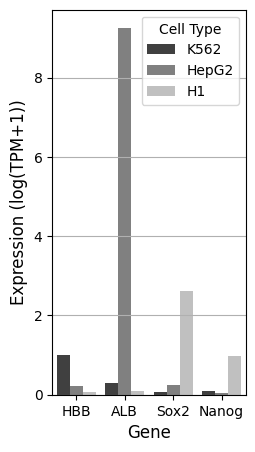

In [25]:
plot_results(results=results)